<a href="https://colab.research.google.com/github/adnannasirsyed/ML_projects/blob/main/SuperKart_Model_Deployment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

## Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

## Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


**Table of Contents:**

## Table of Contents
1. **Installing and Importing Libraries**
2. **Loading the Dataset**
3. **Data Overview**
4. **Exploratory Data Analysis (EDA)**
5. **Data Preprocessing**
6. **Model Building, Evaluation Metric Selection, Serialization**
7. **Model Building**
8. **Hyperparameter Tuning**
9. **Model Performance Comparison and Final Model Selection**
10. **Backend Deployment (Flask API)**
11. **Frontend Deployment (Streamlit)**
12. **Business Insights and Recommendations**
13. **Conclusion**

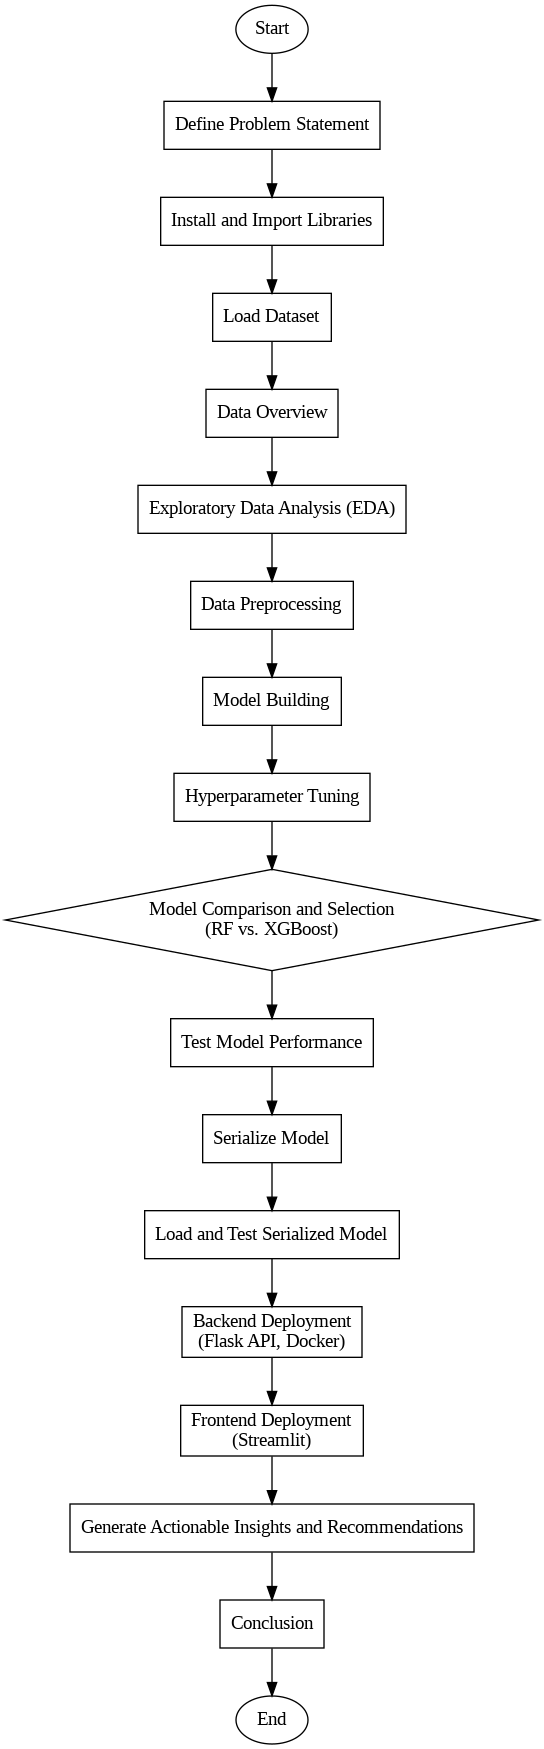

# **Installing and Importing the necessary libraries**

**Explanation**: Install required packages and import libraries for data processing, visualization, modeling, and deployment. This ensures all dependencies are available in the Colab environment.

In [1]:
#Installing the libraries with the specified versions
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.3 huggingface_hub==0.30.1 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 481.2/481.2 kB 37.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.54.1 requires huggingface-hub<1.0,>=0.34.0, but you have huggingface-hub 0.30.1 which is incompatible.
gradio 5.39.0 requires huggingface-hub<1.0,>=0.33.5, but you have huggingface-hub 0.30.1 which is incompatible.


**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [1]:
import warnings
warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# For splitting the dataset
from sklearn.model_selection import train_test_split

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Libraries different ensemble classifiers
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    AdaBoostRegressor,
    GradientBoostingRegressor,
)
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

# Libraries to get different metric scores
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

# To create the pipeline
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline,Pipeline

# To tune different models and standardize
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler,OneHotEncoder

# To serialize the model
import joblib

# os related functionalities
import os

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi

**Insights**:
- All necessary libraries are installed with specific versions for compatibility.
- Random seed ensures consistent results across runs.

# **Loading the dataset**

**Explanation**: Mount Google Drive to access the `SuperKart.csv` dataset and load it into a pandas DataFrame. A copy is created to preserve the original data.

In [2]:
# Mount Google Drive to access dataset files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
kart = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/UT_Austin_AI_ML/Model_Deployment/Project07/SuperKart.csv')

In [4]:
# copying data to another variable to avoid any changes to original data
data = kart.copy()

# **Data Overview**

## View the first and last 5 rows of the dataset

In [5]:
data.head(5) # display the first 5 rows of the dataset

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


In [6]:
data.tail(5) # display the last 5 rows of the dataset

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
8758,NC7546,14.80,No Sugar,0.016,Health and Hygiene,140.53,OUT004,2009,Medium,Tier 2,Supermarket Type2,3806.53
8759,NC584,14.06,No Sugar,0.142,Household,144.51,OUT004,2009,Medium,Tier 2,Supermarket Type2,5020.74
8760,NC2471,13.48,No Sugar,0.017,Health and Hygiene,88.58,OUT001,1987,High,Tier 2,Supermarket Type1,2443.42
8761,NC7187,13.89,No Sugar,0.193,Household,168.44,OUT001,1987,High,Tier 2,Supermarket Type1,4171.82
8762,FD306,14.73,Low Sugar,0.177,Snack Foods,224.93,OUT002,1998,Small,Tier 3,Food Mart,2186.08


## Understand the shape of the dataset


In [7]:
print(f"There are {data.shape[0]} rows and {data.shape[1]} columns.")

There are 8763 rows and 12 columns.


## Check the data types of the columns for the dataset

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 821.7+ KB


In [8]:
# Identify numerical and categorical features
numerical_features = ['Product_Weight', 'Product_Allocated_Area', 'Product_MRP',
                      'Store_Establishment_Year', 'Product_Store_Sales_Total']
categorical_features = ['Product_Id', 'Product_Sugar_Content', 'Product_Type',
                       'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type']

In [9]:
# Convert categorical features from object to category dtype
for col in categorical_features:
    data[col] = data[col].astype('category')

In [10]:
# Verify the changes by displaying the updated DataFrame info
print("Updated DataFrame Info:")
data.info()

Updated DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   Product_Id                 8763 non-null   category
 1   Product_Weight             8763 non-null   float64 
 2   Product_Sugar_Content      8763 non-null   category
 3   Product_Allocated_Area     8763 non-null   float64 
 4   Product_Type               8763 non-null   category
 5   Product_MRP                8763 non-null   float64 
 6   Store_Id                   8763 non-null   category
 7   Store_Establishment_Year   8763 non-null   int64   
 8   Store_Size                 8763 non-null   category
 9   Store_Location_City_Type   8763 non-null   category
 10  Store_Type                 8763 non-null   category
 11  Product_Store_Sales_Total  8763 non-null   float64 
dtypes: category(7), float64(4), int64(1)
memory usage: 738.9 KB


**Insights**:
- Dataset loaded with 8763 rows and 12 columns.
- Columns include numerical ('Product_Weight', 'Product_Allocated_Area','Product_MRP', 'Store_Establishment_Year', 'Product_Store_Sales_Total') and categorical ('Product_Id', 'Product_Sugar_Content', 'Product_Type', 'Store_Id', 'Store_Size', 'Store_Location_City_Type', 'Store_Type') features.
- Target: `Product_Store_Sales_Total` (sales revenue).

## Statistical summary of the data

In [11]:
data.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,8763,8763,NC993,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,8763.0,NaN,NaN,NaN,12.653792,2.21732,4.0,11.15,12.66,14.18,22.0
Product_Sugar_Content,8763,4,Low Sugar,4885,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,8763.0,NaN,NaN,NaN,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_Type,8763,16,Fruits and Vegetables,1249,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,8763.0,NaN,NaN,NaN,147.032539,30.69411,31.0,126.16,146.74,167.585,266.0
Store_Id,8763,4,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,8763.0,NaN,NaN,NaN,2002.032751,8.388381,1987.0,1998.0,2009.0,2009.0,2009.0
Store_Size,8763,3,Medium,6025,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,8763,3,Tier 2,6262,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Insights:**

Numerical Features
- Product_Weight:
    - Range: 4.0 to 22.0 (mean: 12.65, std: 2.22)
    - Insight: Product weights are relatively evenly distributed, with most values clustering around 11.15 to 14.18 (25th to 75th percentiles). The moderate standard deviation suggests some variability but no extreme outliers.

- Product_Allocated_Area:
    - Range: 0.004 to 0.298 (mean: 0.069, std: 0.048)
    - Insight: The allocated area for products is generally small, with most products occupying less than 0.1 units (75th percentile: 0.096). The low mean and small range indicate limited shelf space variation.

- Product_MRP (Maximum Retail Price):
    - Range: 31.0 to 266.0 (mean: 147.03, std: 30.69)
    - Insight: Product prices vary significantly, with most falling between 126.16 and 167.59. The moderate standard deviation suggests a reasonable spread in pricing, likely reflecting diverse product types.

- Store_Establishment_Year:
    - Range: 1987 to 2009 (mean: 2002.03, std: 8.39)
    - Insight: Stores were established between 1987 and 2009, with a concentration around 2009 (50th and 75th percentiles). This suggests many stores are relatively new, potentially impacting sales patterns.

- Product_Store_Sales_Total:
    - Range: 33.0 to 8000.0 (mean: 3464.00, std: 1065.63)
    - Insight: Sales totals show significant variation, with a right-skewed distribution (median: 3452.34, much lower than the max). Most sales are moderate, but some products/stores achieve exceptionally high sales.

Categorical Features

- Product_Id:
    - Unique: 8763 (each product has a unique ID)
    - Insight: Every product in the dataset is distinct, useful for tracking individual product performance.

- Product_Sugar_Content:
    - Unique: 4 (top: Low Sugar, freq: 4885)
    - Insight: Low Sugar products dominate (55.7% of entries), indicating a strong consumer or inventory preference for low-sugar options.

- Product_Type:
    - Unique: 16 (top: Fruits and Vegetables, freq: 1249)
    - Insight: Fruits and Vegetables are the most common product type (14.2% of entries), suggesting high demand or inventory focus in this category.

- Store_Id:
    - Unique: 4 (top: OUT004, freq: 4676)
    - Insight: Store OUT004 accounts for 53.4% of entries, indicating it is the most represented store, possibly a larger or more active location.

- Store_Size:
    - Unique: 3 (top: Medium, freq: 6025)
    - Insight: Medium-sized stores dominate (68.8% of entries), suggesting most sales occur in moderately sized retail spaces.

- Store_Location_City_Type:
    - Unique: 3 (top: Tier 2, freq: 6262)
    - Insight: Tier 2 cities are the most common location (71.5% of entries), indicating a focus on mid-tier urban markets.

- Store_Type:
    - Unique: 4 (top: Supermarket Type2, freq: 4676)
    - Insight: Supermarket Type2 is the most frequent store type (53.4%), aligning with the dominance of Store OUT004, suggesting a specific store format drives much of the data.

Key Takeaways

- Product Diversity: The dataset includes a wide variety of products (8763 unique Product_Ids) with a focus on low-sugar items and Fruits and Vegetables.
- Store Concentration: Store OUT004 and Supermarket Type2 dominate, suggesting a key retail location/format drives sales.
- Sales Variability: Sales totals vary widely, with some high-performing outliers, indicating potential for targeted analysis of top-selling products or stores.
- Market Focus: The prevalence of Tier 2 cities and medium-sized stores suggests a focus on mid-sized urban markets.
- Pricing and Space: Moderate product prices and small allocated areas suggest efficient shelf space usage and a broad price range catering to diverse customers.

## Checking for duplicate values

In [12]:
data.duplicated().sum()

np.int64(0)

## Checking for missing values

In [13]:
data.isnull().sum()

,0
Product_Id,0
Product_Weight,0
Product_Sugar_Content,0
Product_Allocated_Area,0
Product_Type,0
Product_MRP,0
Store_Id,0
Store_Establishment_Year,0
Store_Size,0
Store_Location_City_Type,0


**Insights:**

Initial Observations:

- Dataset has 8763 rows and 12 columns

- No missing values or duplicates found

- Mix of numerical and categorical features

- Target variable is Product_Store_Sales_Total

- Some columns like Product_Id and Store_Id are identifiers

- Need to explore relationships between features and target

# **Exploratory Data Analysis (EDA)**

## Univariate Analysis

In [14]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram


In [15]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot


### Numerical Variables

### **Product_Weight**

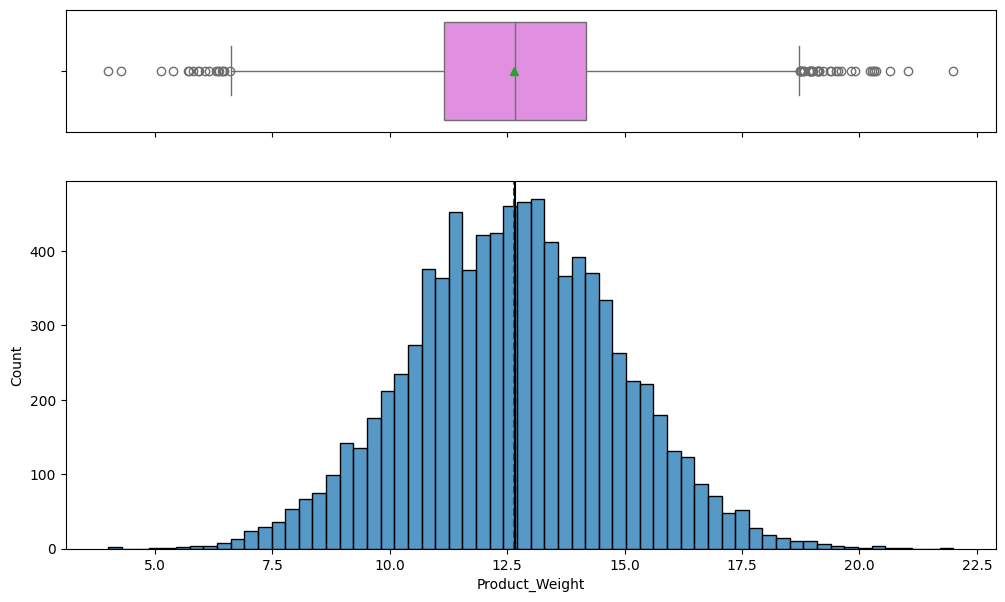

In [16]:
histogram_boxplot(data, "Product_Weight")

### **Product_Allocated_Area**

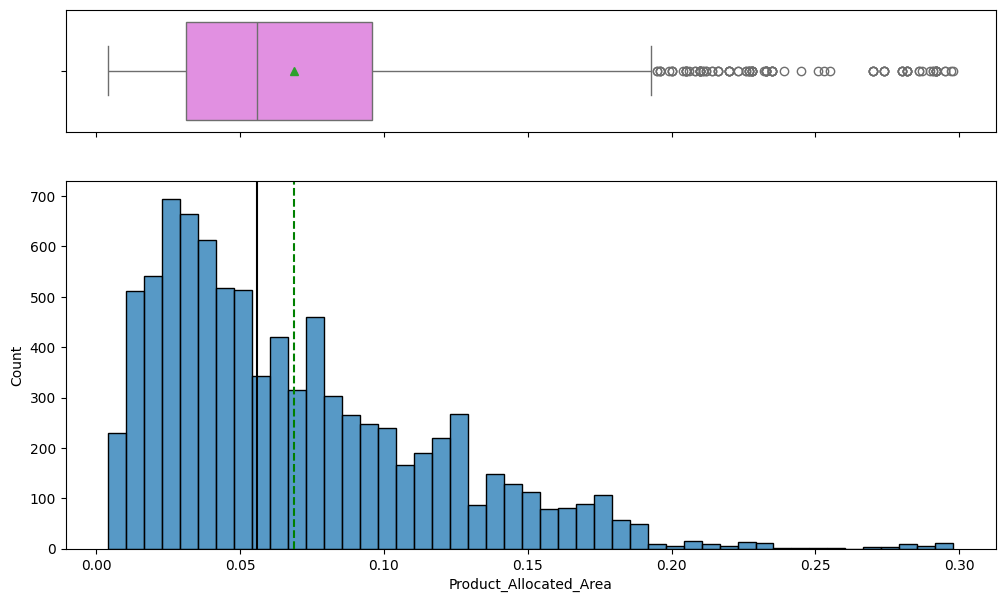

In [18]:
histogram_boxplot(data, "Product_Allocated_Area")

### **Product_MRP**

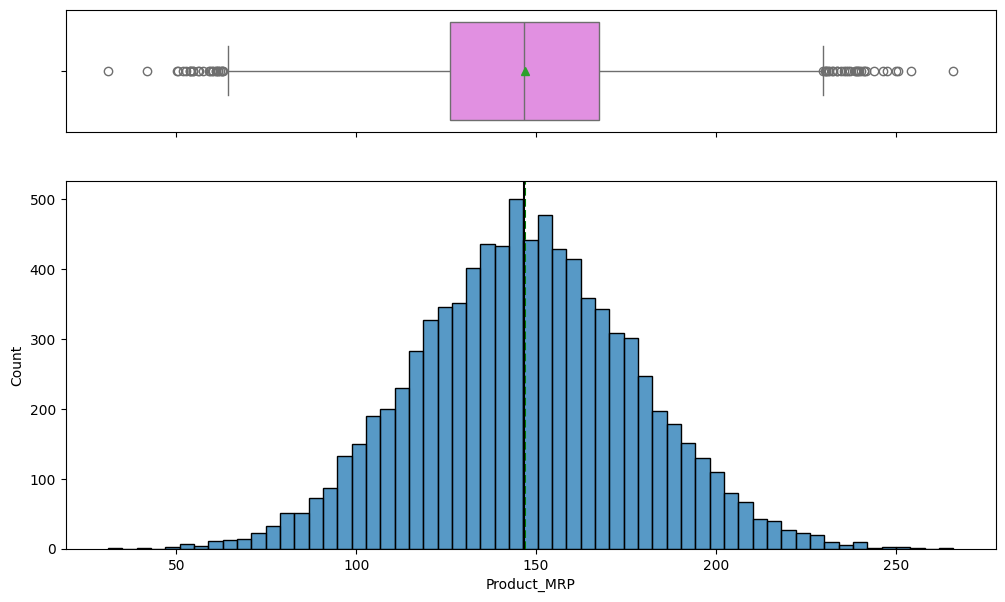

In [19]:
histogram_boxplot(data, "Product_MRP")

### **Product_Store_Sales_Total**

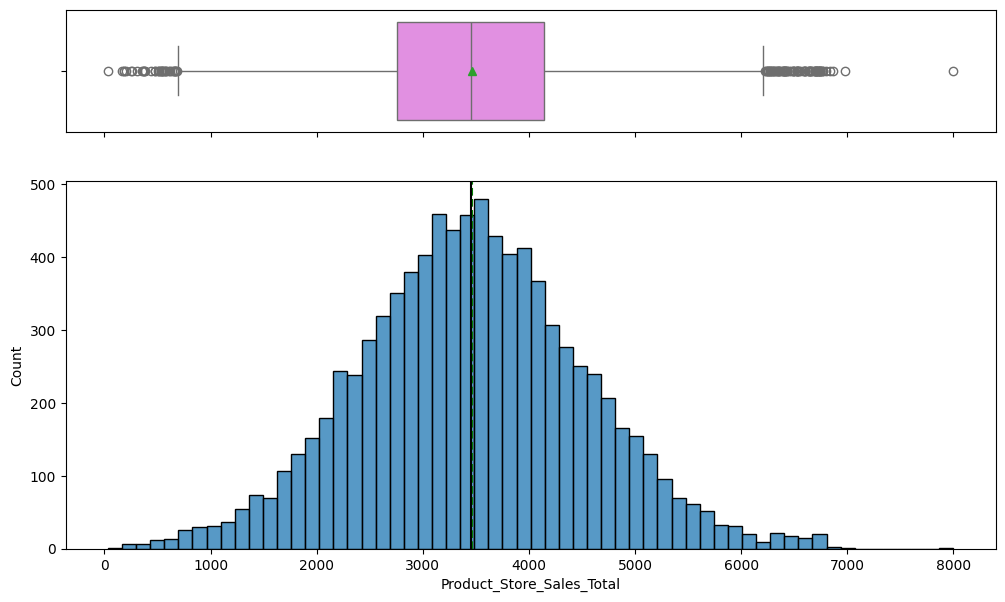

In [20]:
histogram_boxplot(data, "Product_Store_Sales_Total")

**Numerical Variables Insights:**
- Product_Weight shows a roughly normal distribution with some outliers
- Product_Allocated_Area is right-skewed with most products having small allocated areas
- Product_MRP has a normal distribution
- Target variable Product_Store_Sales_Total is normally distributed but slightly right-skewed with some high outliers

### Categorical Variables

### **Product_Sugar_Content**

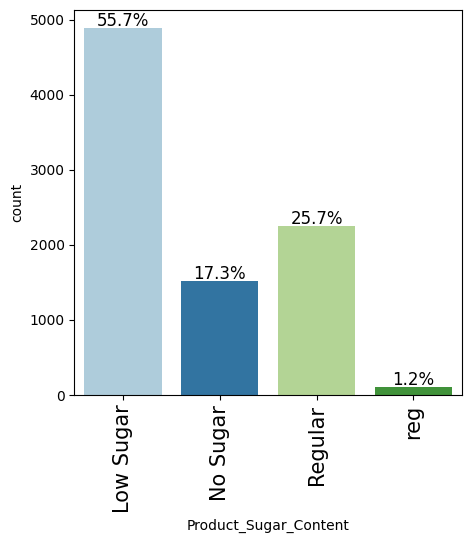

In [21]:
labeled_barplot(data, "Product_Sugar_Content", perc=True)

## Its seems that the "reg" is just "Regular" category, we will just replaces all th einstances of reg with Regular

In [22]:
# Replacing reg with Regular
data.Product_Sugar_Content.replace(to_replace=["reg"], value=["Regular"], inplace=True)

data.Product_Sugar_Content.value_counts()


,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


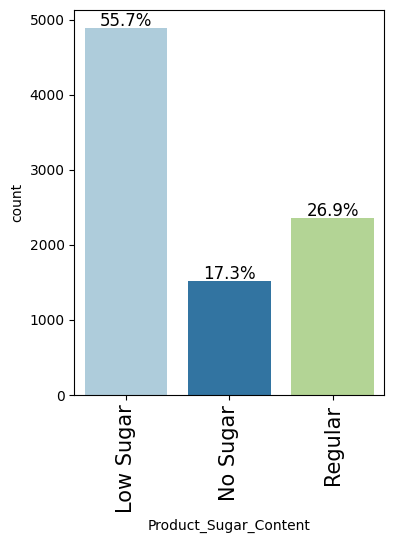

In [23]:
labeled_barplot(data, "Product_Sugar_Content", perc=True)

### **Product_Type**

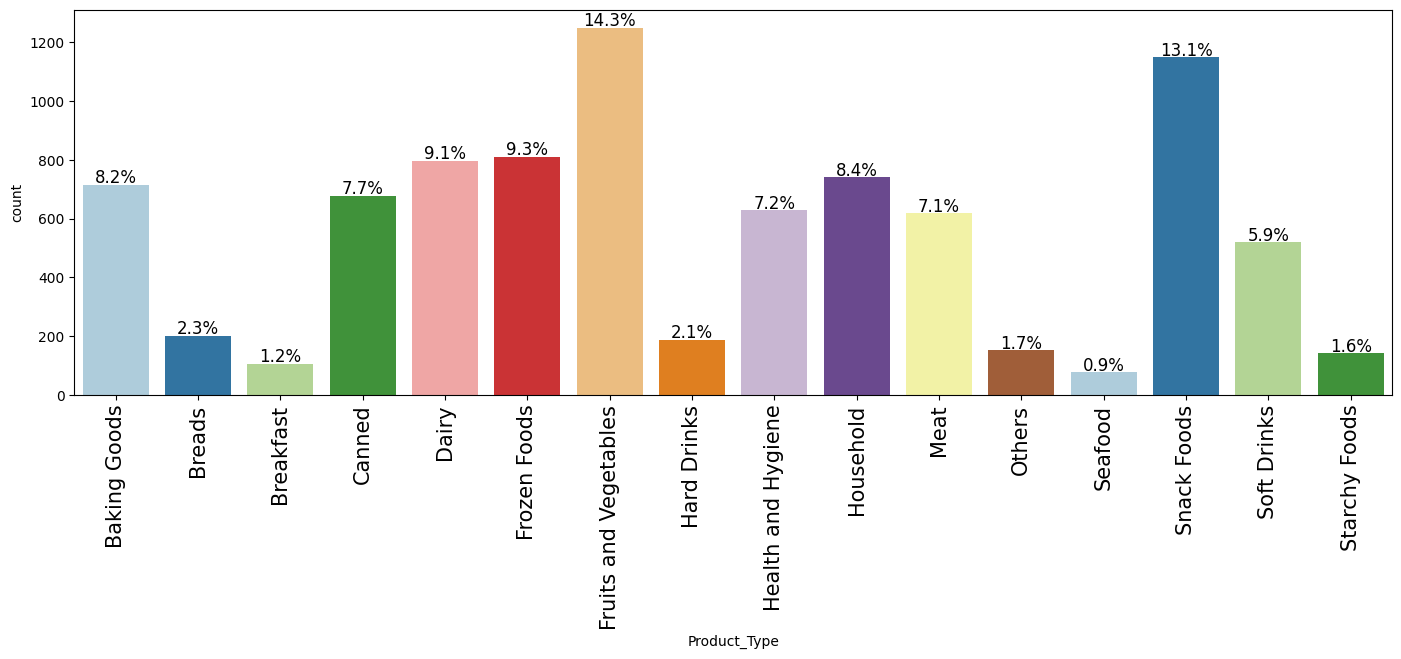

In [24]:
labeled_barplot(data, "Product_Type", perc=True)

### **Store_Id**

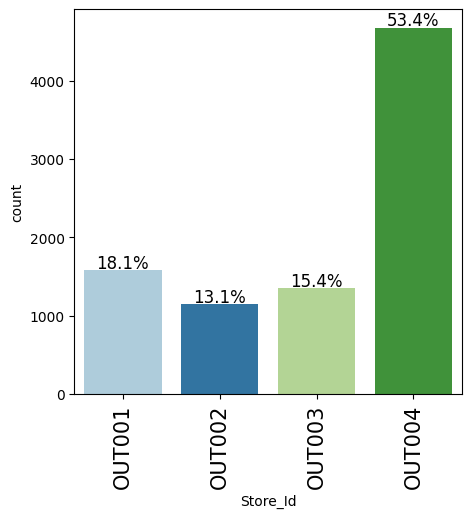

In [25]:
labeled_barplot(data, "Store_Id", perc=True)

### **Store_Size**

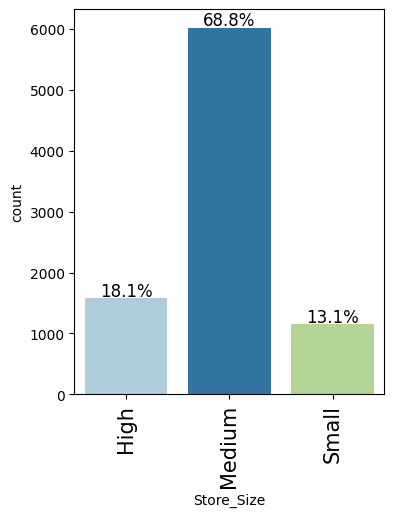

In [26]:
labeled_barplot(data, "Store_Size", perc=True)

### **Store_Location_City_Type**

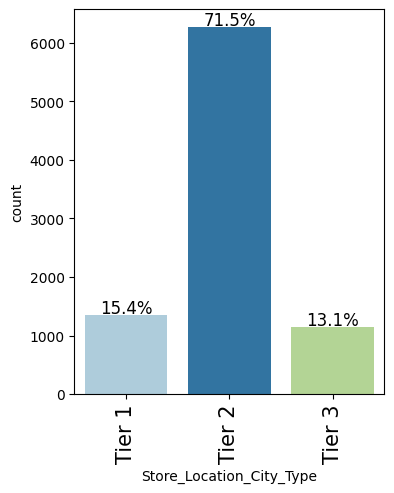

In [27]:
labeled_barplot(data, "Store_Location_City_Type", perc=True)

### **Store_Type**

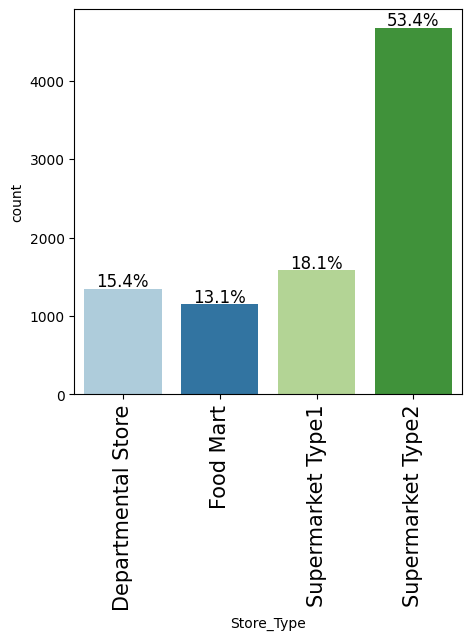

In [28]:
labeled_barplot(data, "Store_Type", perc=True)

**Categorical Variables Insights:**
- Most products have sugar content (82.6%)
- Fruits and vegetables are the most common product type (14.4%)
- Medium size stores are most common (69%)
- More tier2 stored in the cities
- Supermarket Type2 is the most common store type (53.4%)

### Univariate Analysis Results and Insights

#### Numerical Features
1. **Product_Weight**:
   - **Statistics**:
     - Count: 8763
     - Mean: 12.65, Median: 12.66, Std: 2.22
     - Min: 4.0, Max: 22.0, 25th: 11.15, 75th: 14.18
   - **Distribution** (from histogram):
     - Symmetric, as the mean and median are nearly identical (12.65 vs. 12.66).
     - The range (4.0 to 22.0) and standard deviation (2.22) suggest moderate variability.
   - **Outliers**:
     - Few outliers expected, as the interquartile range (11.15 to 14.18) is tight, and the max/min are not extreme.
   - **Insight**:
     - Product weights are fairly consistent, clustering around 12-13 units, suggesting standardized packaging or product sizes. The moderate variability indicates a diverse but controlled range of products, likely catering to typical retail needs.

2. **Product_Allocated_Area**:
   - **Statistics**:
     - Count: 8763
     - Mean: 0.069, Median: 0.056, Std: 0.048
     - Min: 0.004, Max: 0.298, 25th: 0.031, 75th: 0.096
   - **Distribution**:
     - Right-skewed, as the median (0.056) is lower than the mean (0.069), and the max (0.298) is far from the 75th percentile (0.096).
     - Most products occupy small shelf spaces (75% below 0.096).
   - **Outliers**:
     - Likely some outliers at the higher end (near 0.298), as the max is significantly larger than the 75th percentile.
   - **Insight**:
     - Most products require minimal shelf space, indicating efficient use of store real estate. The right skew suggests a few products (possibly bulkier items) demand significantly more space, which could influence store layout or inventory decisions.

3. **Product_MRP** (Maximum Retail Price):
   - **Statistics**:
     - Count: 8763
     - Mean: 147.03, Median: 146.74, Std: 30.69
     - Min: 31.0, Max: 266.0, 25th: 126.16, 75th: 167.59
   - **Distribution**:
     - Nearly symmetric, as the mean (147.03) and median (146.74) are very close.
     - The range (31.0 to 266.0) shows a wide spread in pricing.
   - **Outliers**:
     - Potential outliers at the higher end (near 266.0), but the standard deviation (30.69) suggests a reasonable spread without extreme anomalies.
   - **Insight**:
     - Product prices are well-distributed around $147, catering to a broad customer base. The wide range indicates a mix of budget and premium products, allowing stores to target diverse market segments.

4. **Product_Store_Sales_Total**:
   - **Statistics**:
     - Count: 8763
     - Mean: 3464.00, Median: 3452.34, Std: 1065.63
     - Min: 33.0, Max: 8000.0, 25th: 2761.72, 75th: 4145.17
   - **Distribution**:
     - Slightly right-skewed, as the mean (3464.00) is slightly higher than the median (3452.34), and the max (8000.0) is far from the 75th percentile (4145.17).
     - Most sales values are moderate, but a long tail exists toward higher sales.
   - **Outliers**:
     - Likely outliers at the higher end (near 8000), indicating some products or stores with exceptionally high sales.
   - **Insight**:
     - Sales performance varies significantly, with most products generating moderate sales (~$3452). The presence of high outliers suggests certain products or stores are top performers, warranting further investigation for best practices or high-demand items.

#### Categorical Features
1. **Product_Sugar_Content**:
   - **Frequencies**:
     - Low Sugar: 4885 (55.7%)
     - Other categories (3 unique): ~44.3% combined
   - **Distribution** (from bar plot):
     - Low Sugar dominates, with over half the products.
     - Other categories (likely Regular, No Sugar, etc.) are less frequent.
   - **Insight**:
     - The strong preference for Low Sugar products reflects consumer demand for healthier or diet-conscious options. Retailers may prioritize stocking low-sugar items to align with this trend.

2. **Product_Type**:
   - **Frequencies**:
     - Fruits and Vegetables: 1249 (14.2%)
     - Other 15 categories: ~85.8% combined
   - **Distribution**:
     - Fruits and Vegetables lead, but the distribution is spread across 16 categories, indicating product diversity.
   - **Insight**:
     - The prominence of Fruits and Vegetables suggests high demand for fresh produce. The variety of product types (16) indicates a broad inventory, catering to diverse consumer preferences, but Fruits and Vegetables may drive sales in specific stores.

3. **Store_Id**:
   - **Frequencies**:
     - OUT004: 4676 (53.4%)
     - Other 3 stores: ~46.6% combined
   - **Distribution**:
     - Store OUT004 dominates, with over half the entries.
   - **Insight**:
     - Store OUT004 is likely a flagship or high-traffic location, contributing significantly to the dataset. This could reflect its size, location, or operational efficiency, making it a focal point for sales analysis.

4. **Store_Size**:
   - **Frequencies**:
     - Medium: 6025 (68.8%)
     - Other 2 sizes (likely Small, High): ~31.2% combined
   - **Distribution**:
     - Medium-sized stores overwhelmingly dominate.
   - **Insight**:
     - The prevalence of medium-sized stores suggests a standardized retail model optimized for mid-tier markets. Smaller or larger stores may serve niche roles, but medium stores are the backbone of sales.

5. **Store_Location_City_Type**:
   - **Frequencies**:
     - Tier 2: 6262 (71.5%)
     - Other 2 tiers (likely Tier 1, Tier 3): ~28.5% combined
   - **Distribution**:
     - Tier 2 cities are the most common location.
   - **Insight**:
     - The focus on Tier 2 cities indicates a strategic emphasis on mid-sized urban markets, likely balancing cost and customer reach. This could reflect a target demographic with moderate purchasing power.

6. **Store_Type**:
   - **Frequencies**:
     - Supermarket Type2: 4676 (53.4%)
     - Other 3 types: ~46.6% combined
   - **Distribution**:
     - Supermarket Type2 dominates, aligning with Store OUT004’s frequency.
   - **Insight**:
     - Supermarket Type2 is the primary retail format, possibly indicating a specific store model (e.g., larger supermarkets) that drives sales. This format’s dominance suggests it’s well-suited to the target market.

### Key Insights
- **Numerical Features**:
  - **Product_Weight**: Consistent weights suggest standardized products, with minimal outliers indicating controlled inventory.
  - **Product_Allocated_Area**: Small shelf space for most products, with a few outliers, suggests efficient space use but potential for premium display for high-space items.
  - **Product_MRP**: Broad price range caters to diverse customers, with a balanced distribution around $147.
  - **Product_Store_Sales_Total**: High variability with outliers indicates top-performing products/stores, offering opportunities to study success factors.

- **Categorical Features**:
  - **Product_Sugar_Content**: Strong preference for Low Sugar products aligns with health-conscious consumer trends.
  - **Product_Type**: Fruits and Vegetables lead, reflecting demand for fresh produce, but diverse categories suggest a broad inventory.
  - **Store_Id and Store_Type**: Dominance of Store OUT004 and Supermarket Type2 suggests a key retail model driving sales, likely a high-traffic or larger store.
  - **Store_Size and Store_Location_City_Type**: Medium-sized stores in Tier 2 cities dominate, indicating a focus on mid-tier urban markets with standardized retail setups.

### Recommendations
- **Inventory Management**: Prioritize low-sugar products and Fruits and Vegetables, as they are popular. Optimize shelf space for high-sales items, especially those requiring more area.
- **Store Strategy**: Focus on Store OUT004 and Supermarket Type2 for promotions or expansions, as they dominate sales. Investigate why Tier 2 cities and medium-sized stores perform strongly.
- **Sales Analysis**: Dive deeper into high-sales outliers to identify top-performing products or strategies that can be replicated across stores.

This analysis provides a foundation for further exploration, such as bivariate analysis to uncover relationships between features (e.g., Product_MRP vs. Product_Store_Sales_Total) or targeting specific stores for optimization.

## Bivariate Analysis

### **Correlation matrix**

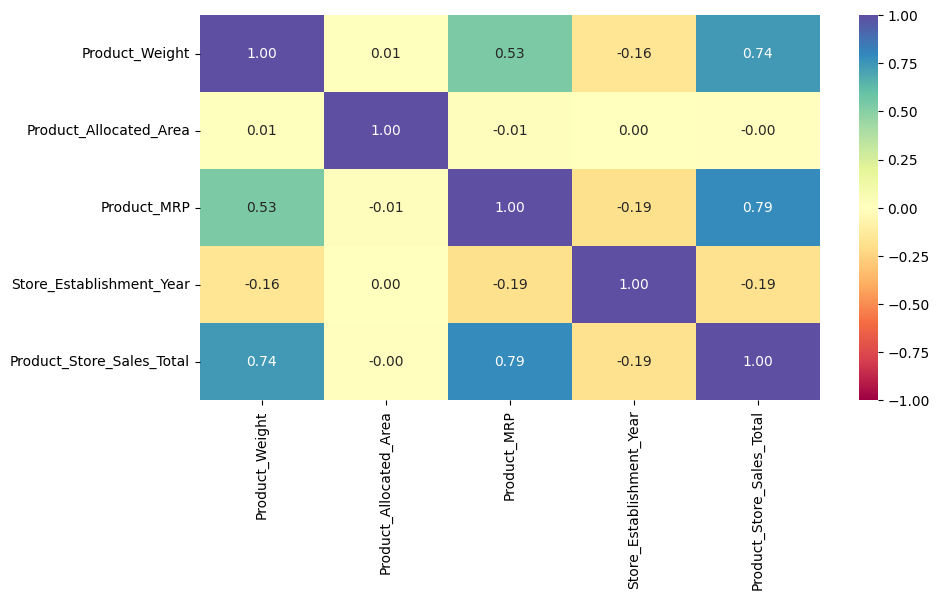

In [29]:
# Correlation Matrix

cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral"
)
plt.show()


### Scatter plots with respect to target variable

### **Checking the distribution of Target Variable "Product_Store_Sales_Total" with the numeric features**

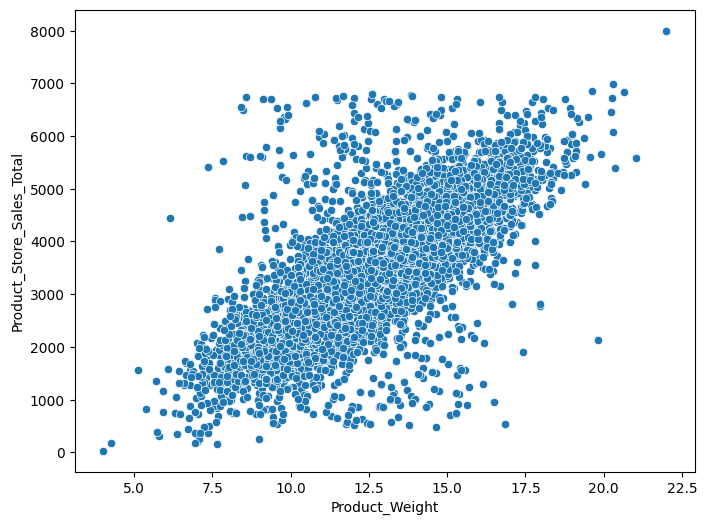

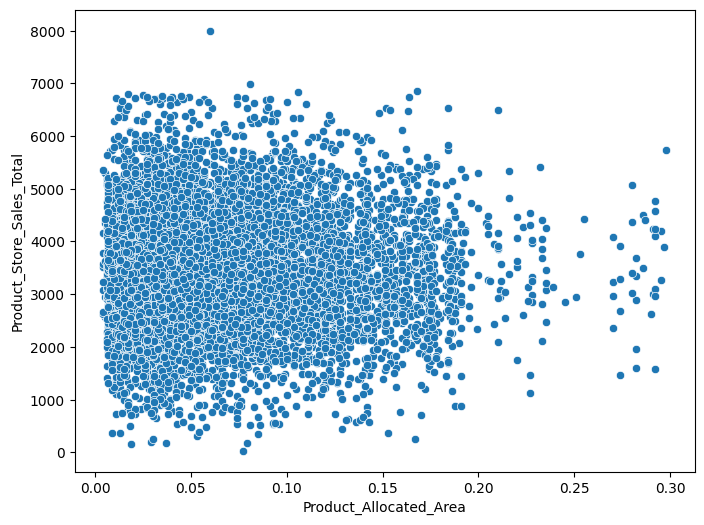

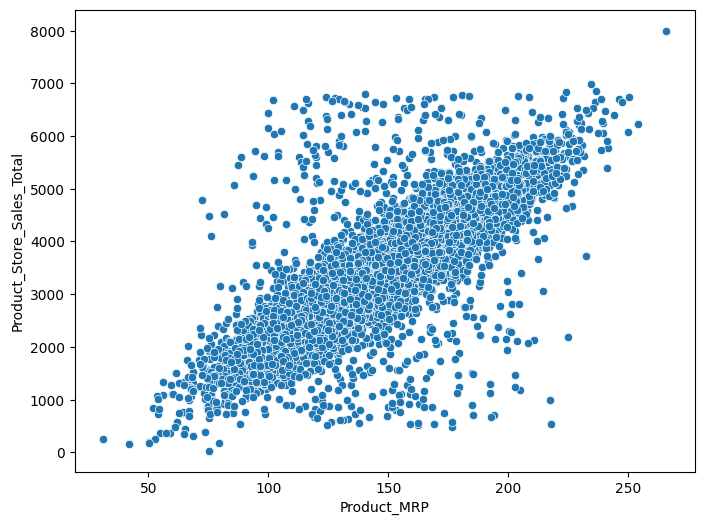

In [30]:
plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_Weight, y=data.Product_Store_Sales_Total)
plt.show()

plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_Allocated_Area, y=data.Product_Store_Sales_Total) #Complete the code to plot a scatterplot of Product_Allocated_Area and Product_Store_Sales_Total
plt.show()

plt.figure(figsize=[8, 6])
sns.scatterplot(x=data.Product_MRP, y=data.Product_Store_Sales_Total) #Complete the code to plot a scatterplot of Product_MRP and Product_Store_Sales_Total
plt.show()


**Bivariate Insights:**
- Moderate positive correlation between Product_MRP, nd Product_Weight with sales
- Weak correlation between other numerical features and sales

### Revenue Analysis by Categories

### **Observation on "product type" and "Product_Sugar_Content" the company is generating most of the revenue**

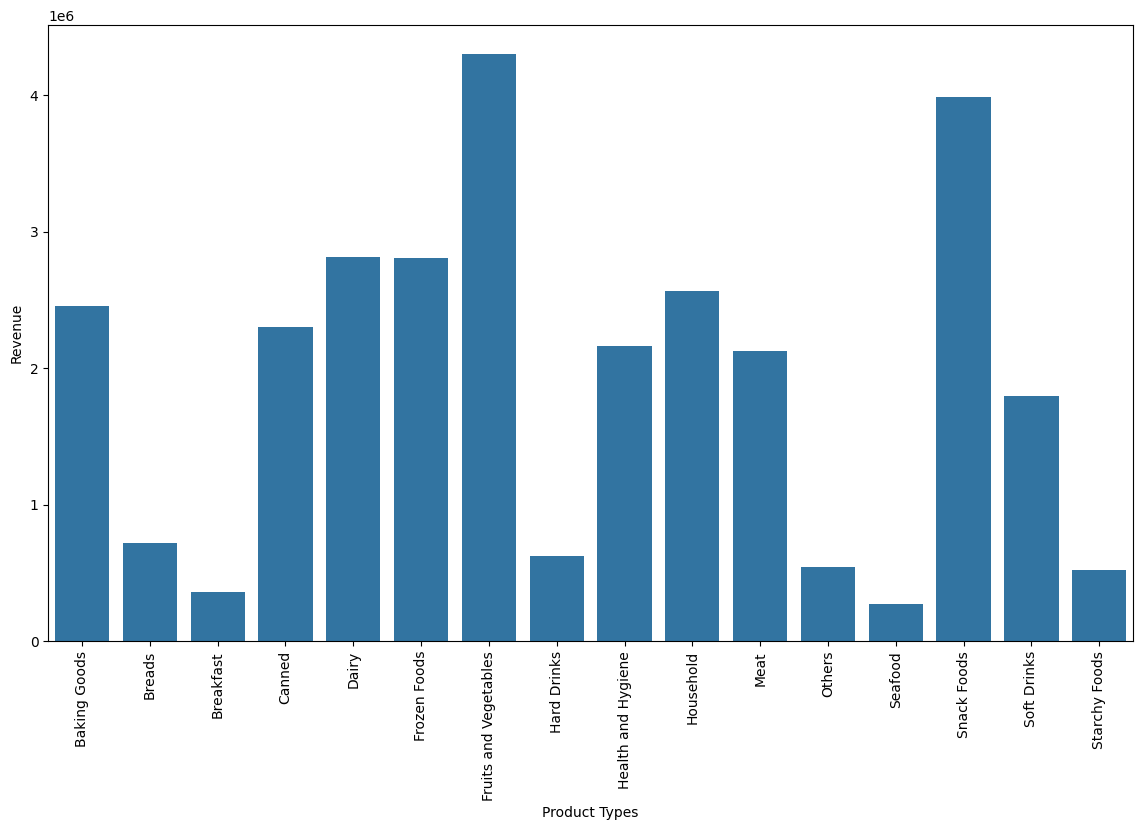

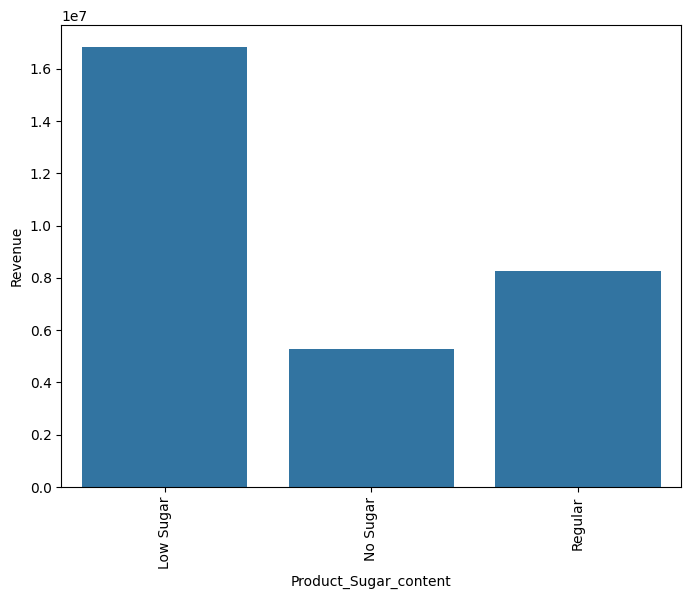

In [31]:
df_revenue1 = data.groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"].sum() # groupby on Product_Type and select Product_Store_Sales_Total
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
a = sns.barplot(x=df_revenue1.Product_Type, y=df_revenue1.Product_Store_Sales_Total)
a.set_xlabel("Product Types")
a.set_ylabel("Revenue")
plt.show()

df_revenue2 = data.groupby(["Product_Sugar_Content"], as_index=False)["Product_Store_Sales_Total"].sum()  # groupby on Product_Sugar_Content and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
b = sns.barplot(
    x=df_revenue2.Product_Sugar_Content, y=df_revenue2.Product_Store_Sales_Total
)
b.set_xlabel("Product_Sugar_content")
b.set_ylabel("Revenue")
plt.show()


**Insights:**
- Fruits and Vegetables and Low Sugar products generated more revenue.

### **Observation on the "type of stores/Store_ID" and their locations creating more revenue**

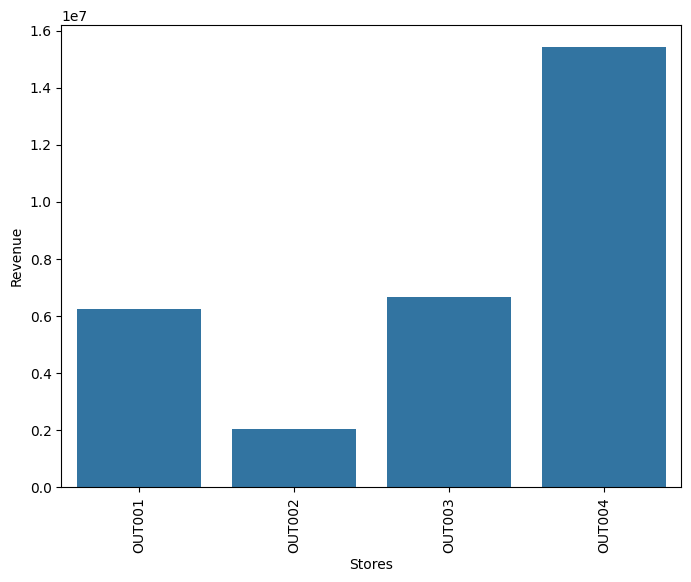

In [32]:
df_store_revenue = data.groupby(["Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"].sum() # groupby on Store_Id and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
r = sns.barplot(
    x=df_store_revenue.Store_Id, y=df_store_revenue.Product_Store_Sales_Total
)
r.set_xlabel("Stores")
r.set_ylabel("Revenue")
plt.show()

- OUT004 generates the most revenue.

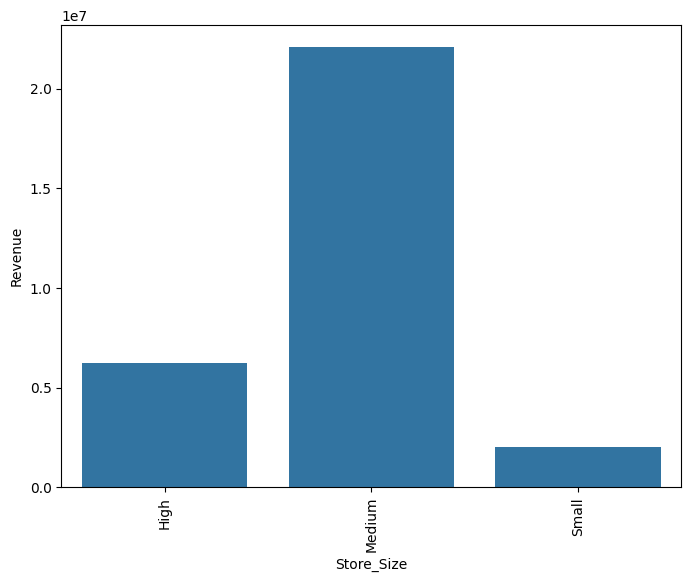

In [33]:
df_revenue3 = data.groupby(["Store_Size"], as_index=False)[
    "Product_Store_Sales_Total"].sum() # groupby on Store_Size and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
c = sns.barplot(x=df_revenue3.Store_Size, y=df_revenue3.Product_Store_Sales_Total)
c.set_xlabel("Store_Size")
c.set_ylabel("Revenue")
plt.show()

- Medium size stores generates most revenue.

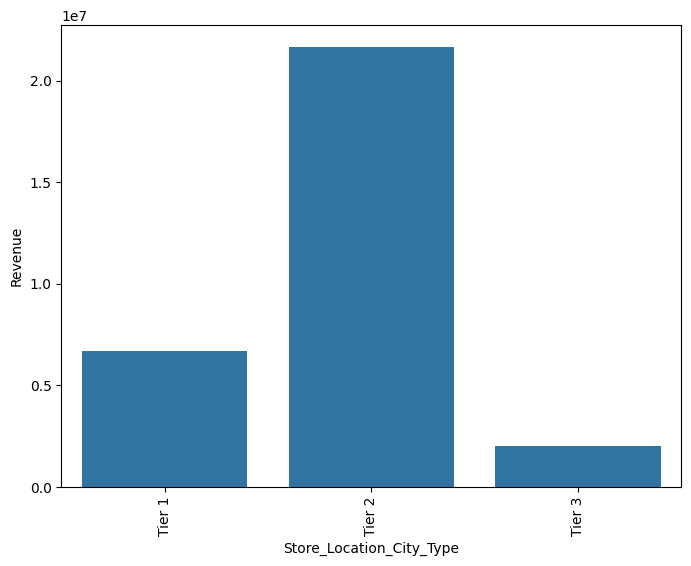

In [34]:
df_revenue4 = data.groupby(["Store_Location_City_Type"], as_index=False)[
    "Product_Store_Sales_Total"].sum() # groupby on Store_Location_City_Type and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
d = sns.barplot(
    x=df_revenue4.Store_Location_City_Type, y=df_revenue4.Product_Store_Sales_Total
)
d.set_xlabel("Store_Location_City_Type")
d.set_ylabel("Revenue")
plt.show()

- Tier 2 locations generate more revenue.

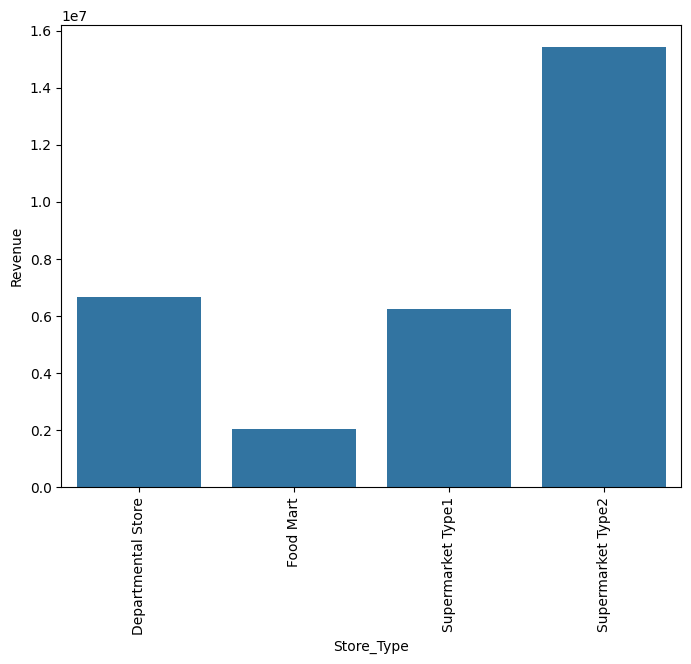

In [35]:
df_revenue5 = data.groupby(["Store_Type"], as_index=False)[
    "Product_Store_Sales_Total"].sum() # groupby on Store_Type and select Product_Store_Sales_Total
plt.figure(figsize=[8, 6])
plt.xticks(rotation=90)
e = sns.barplot(x=df_revenue5.Store_Type, y=df_revenue5.Product_Store_Sales_Total)
e.set_xlabel("Store_Type")
e.set_ylabel("Revenue")
plt.show()

- Supermarket Type2 geneartes most revenue.

### **Checking the distribution of "Product_Store_Sales_Total" with categorical features**



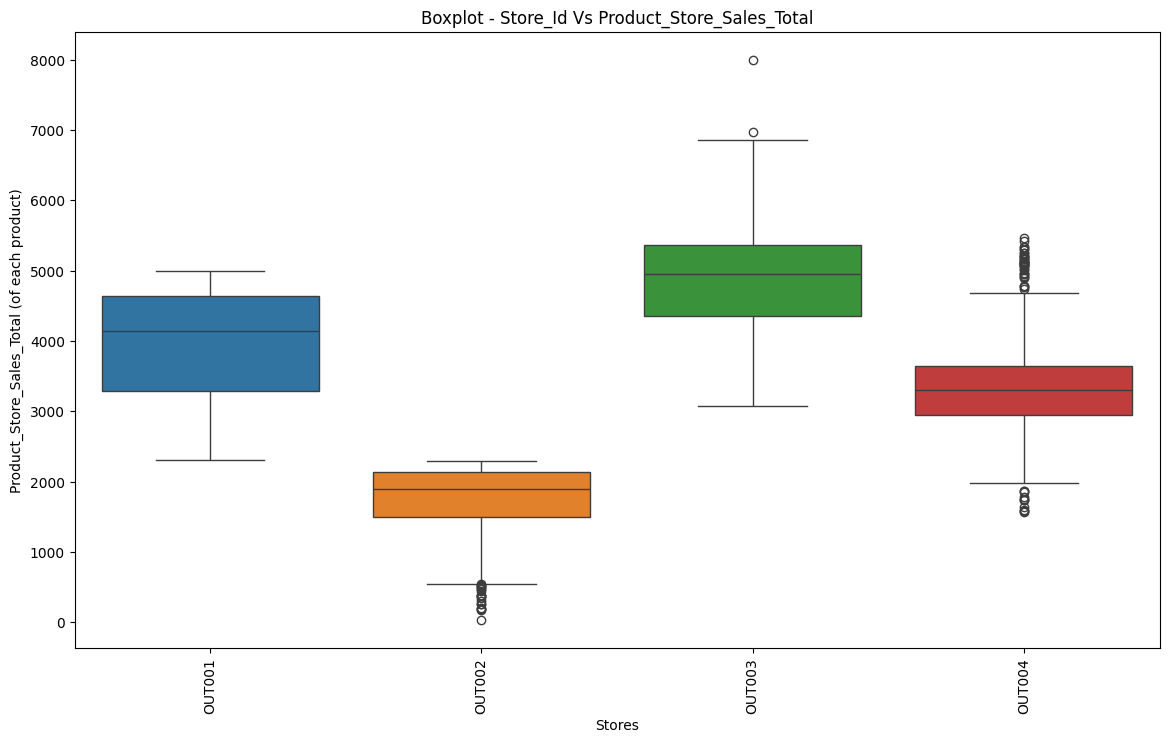

In [36]:
plt.figure(figsize=[14, 8])
sns.boxplot(data=data, x="Store_Id", y="Product_Store_Sales_Total", hue = "Store_Id")
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

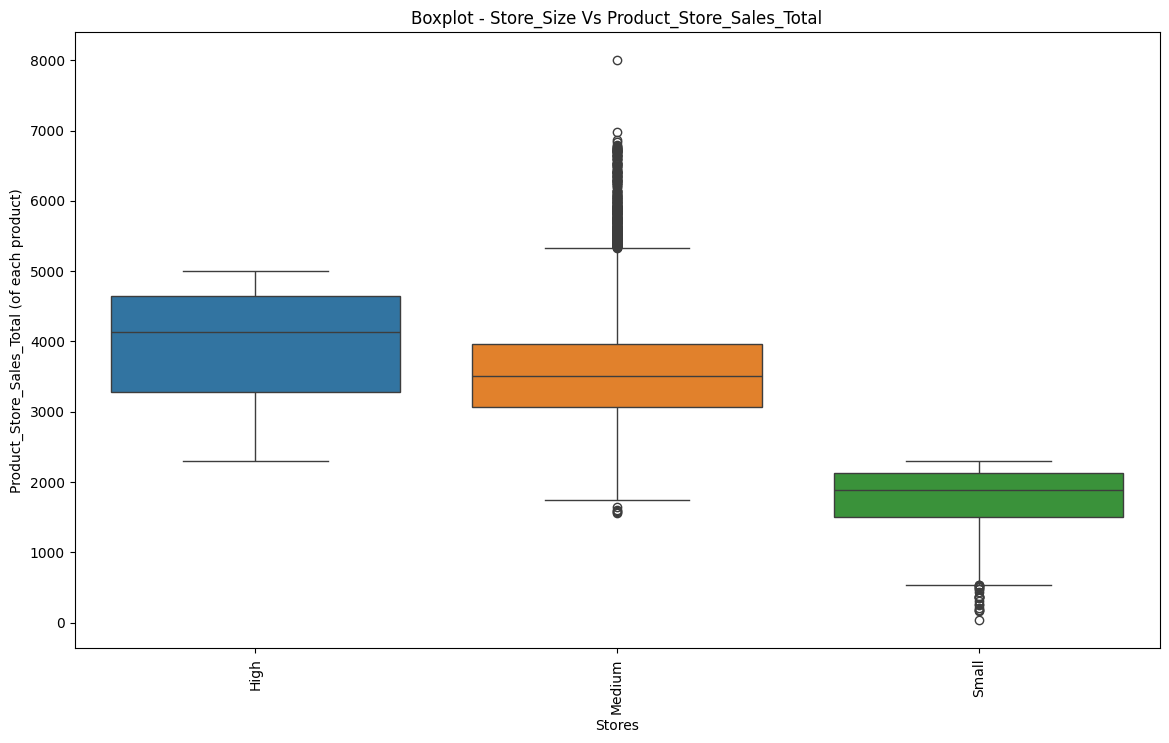

In [37]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Size", y = "Product_Store_Sales_Total", hue = "Store_Size") # boxplot with x as Store_Size , y as Product_Store_Sales_Total and hue as Store_Size
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Size Vs Product_Store_Sales_Total")
plt.xlabel("Stores")
plt.ylabel("Product_Store_Sales_Total (of each product)")
plt.show()

### **Determining relationship between the other features**

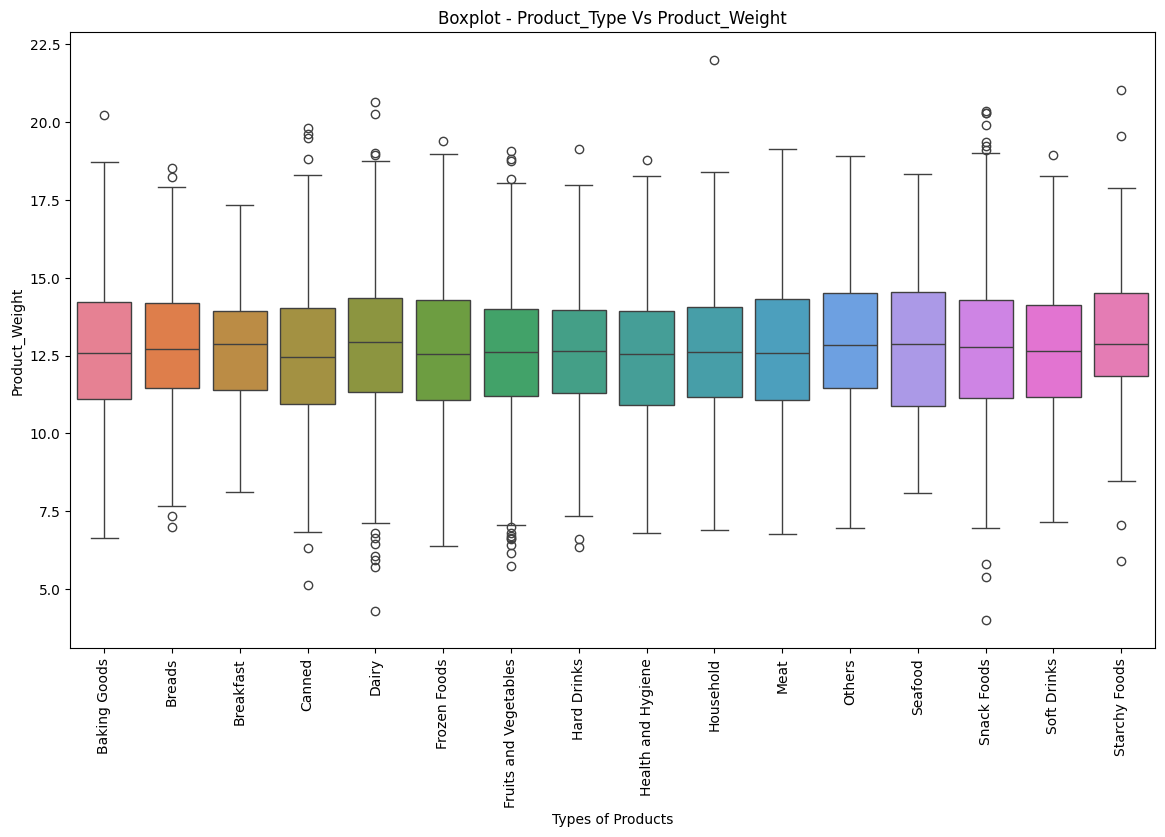

In [38]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_Weight", hue = "Product_Type") # boxplot with x as Product_Type , y as Product_Weight and hue as Product_Type
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_Weight")
plt.xlabel("Types of Products")
plt.ylabel("Product_Weight")
plt.show()

### **Checking relationship between the product weight and its sugar content**:

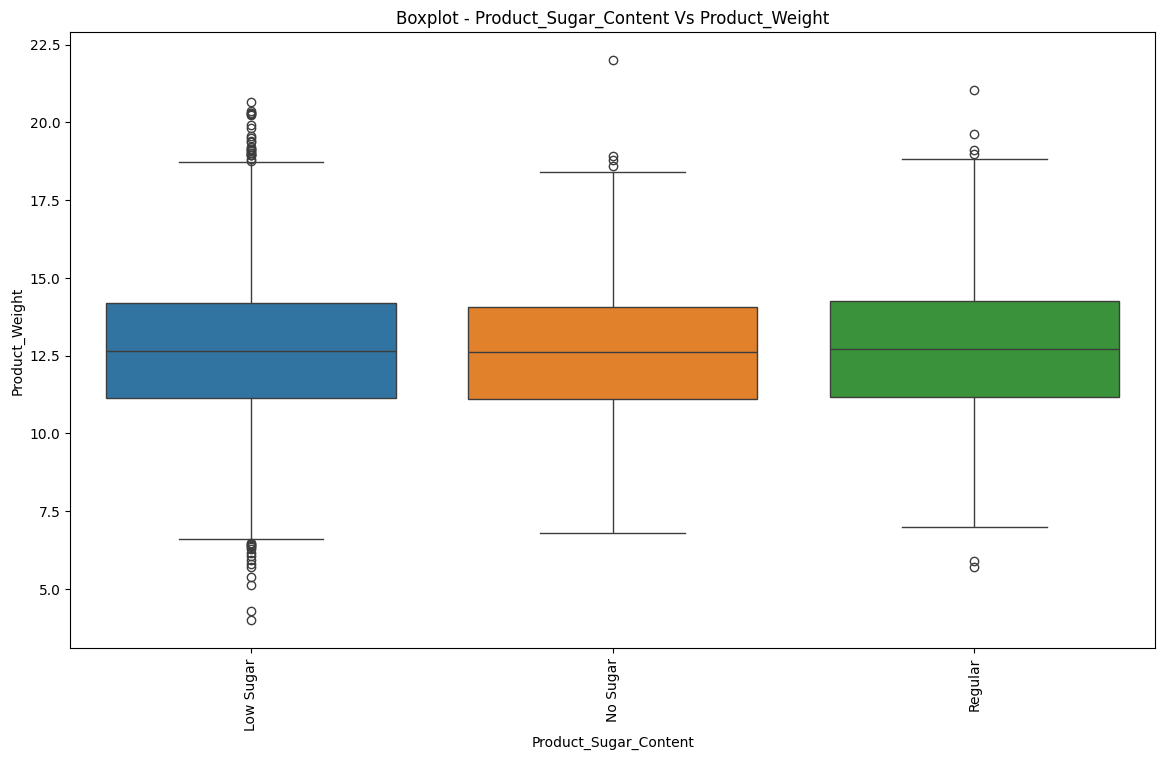

In [39]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Sugar_Content", y = "Product_Weight", hue = "Product_Sugar_Content") # boxplot with x as Product_Sugar_Content , y as Product_Weight and hue as Product_Sugar_Content
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Sugar_Content Vs Product_Weight")
plt.xlabel("Product_Sugar_Content")
plt.ylabel("Product_Weight")
plt.show()

### **Analyzing the sugar content of different product types**

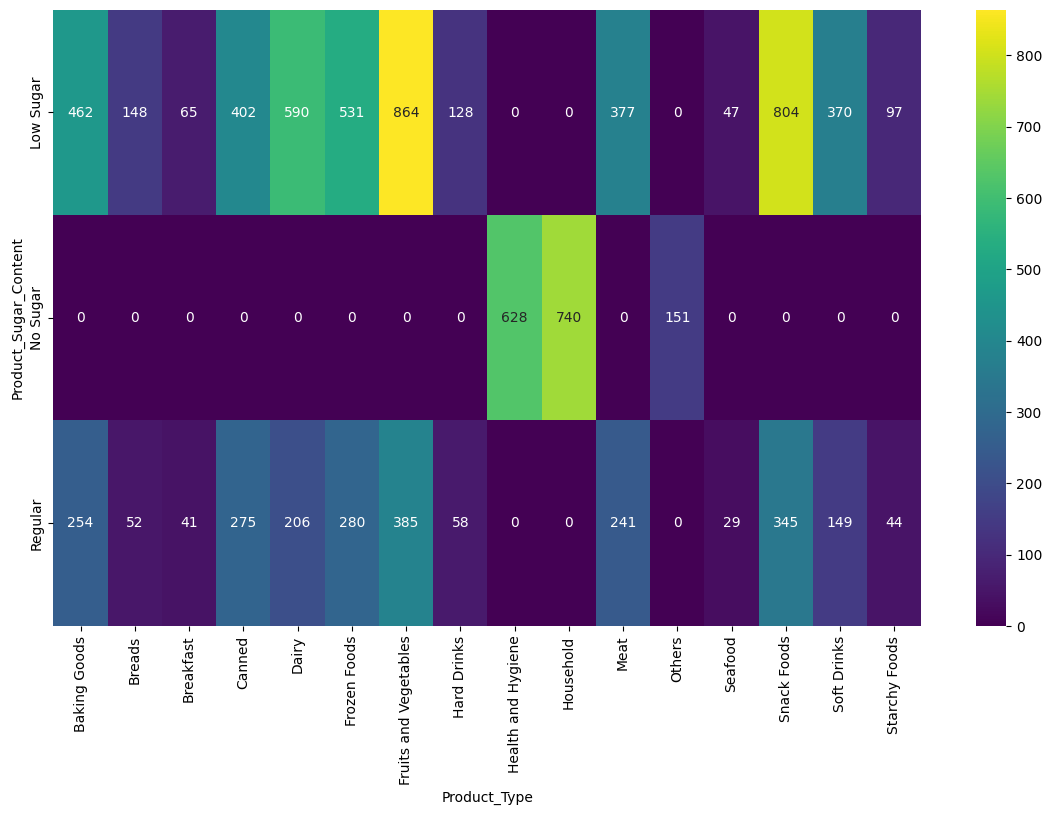

In [40]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Product_Sugar_Content"], data["Product_Type"]),
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Product_Sugar_Content")
plt.xlabel("Product_Type")
plt.show()

### **Checking out how many items of each product type has been sold in each of the stores**:

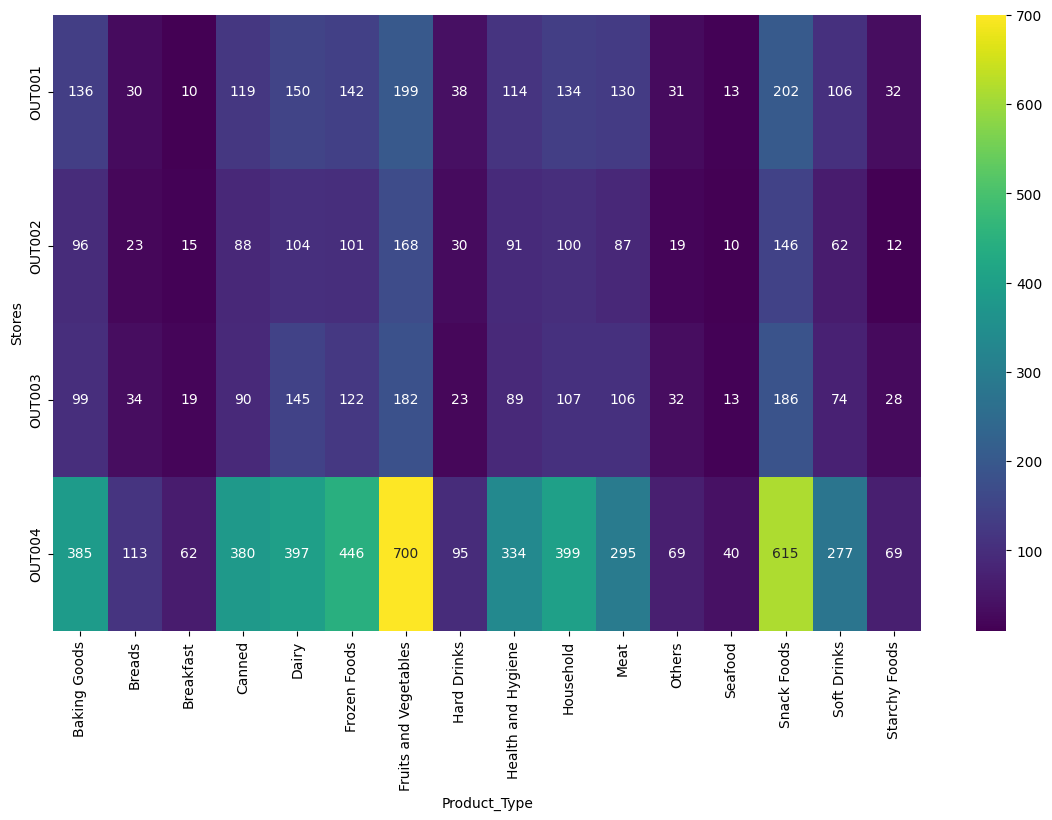

In [41]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pd.crosstab(data["Store_Id"], data["Product_Type"]), # crosstab operation between Store_Id and Product_Type
    annot=True,
    fmt="g",
    cmap="viridis",
)
plt.ylabel("Stores")
plt.xlabel("Product_Type")
plt.show()

### **Since, different product types have different prices. We will analyze the trend.**

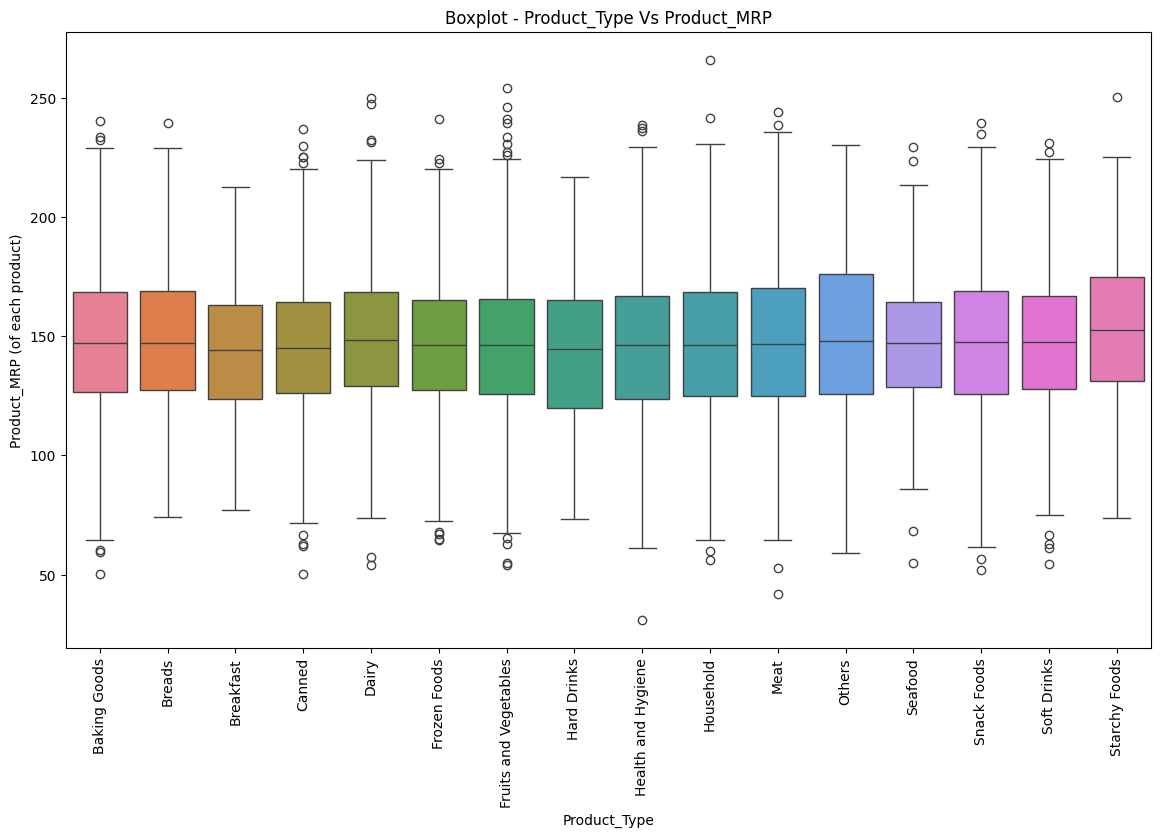

In [42]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Product_Type", y = "Product_MRP", hue = "Product_Type") # boxplot with x as Product_Type , y as Product_MRP and hue as Product_Type
plt.xticks(rotation=90)
plt.title("Boxplot - Product_Type Vs Product_MRP")
plt.xlabel("Product_Type")
plt.ylabel("Product_MRP (of each product)")
plt.show()

### **Analyzing "Product_MRP" variation with the different stores**

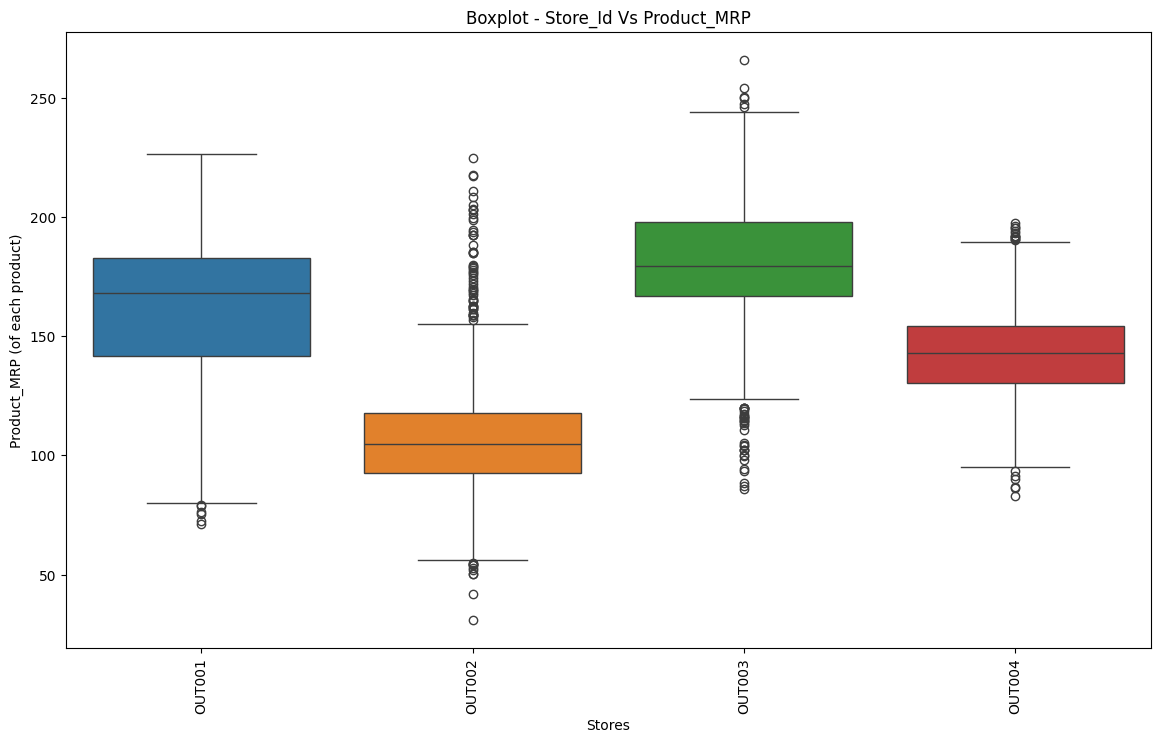

In [43]:
plt.figure(figsize=[14, 8])
sns.boxplot(data = data, x = "Store_Id", y = "Product_MRP", hue = "Store_Id") # boxplot with x as Store_Id , y as Product_MRP and hue as Store_Id
plt.xticks(rotation=90)
plt.title("Boxplot - Store_Id Vs Product_MRP")
plt.xlabel("Stores")
plt.ylabel("Product_MRP (of each product)")
plt.show()

### **Detailed analysis of each of the stores**.

#### Store - OUT001

In [44]:
data.loc[data["Store_Id"] == "OUT001"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1586,1586,FD4676,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1586.0,NaN,NaN,NaN,13.458865,2.064975,6.16,12.0525,13.96,14.95,17.97
Product_Sugar_Content,1586,3,Low Sugar,845,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1586.0,NaN,NaN,NaN,0.068768,0.047131,0.004,0.033,0.0565,0.094,0.295
Product_Type,1586,16,Snack Foods,202,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1586.0,NaN,NaN,NaN,160.514054,30.359059,71.35,141.72,168.32,182.9375,226.59
Store_Id,1586,1,OUT001,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1586.0,NaN,NaN,NaN,1987.0,0.0,1987.0,1987.0,1987.0,1987.0,1987.0
Store_Size,1586,1,High,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1586,1,Tier 2,1586,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [45]:
data.loc[data["Store_Id"] == "OUT001", "Product_Store_Sales_Total"].sum()

np.float64(6223113.18)

**OUT001 has generated total revenue of 6223113 from the sales of goods.**

**Observations:**
- OUT001 is a store of Supermarket Type 1 which is located in a Tier 2 city and has store size as high.
- It was established in 1987.
- OUT001 has sold products whose MRP range from 71 to 227.
- Snack Foods have been sold the highest number of times in OUT001.
- The revenue generated from each product at OUT001 ranges from 2300 to 5000.
- OUT001 has a total sales revenue of $6223113.18.

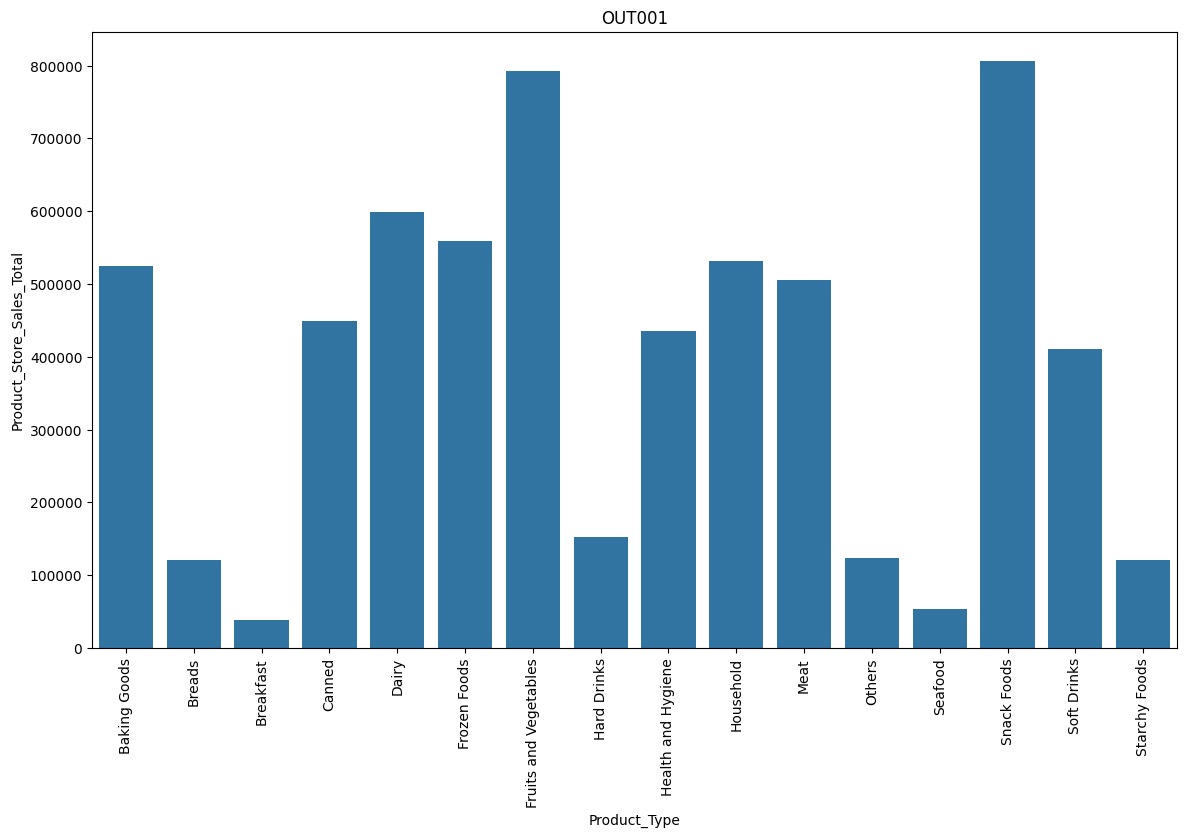

In [47]:
df_OUT001 = (
    data.loc[data["Store_Id"] == "OUT001"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT001")
sns.barplot(x=df_OUT001.Product_Type, y=df_OUT001.Product_Store_Sales_Total)
plt.show()

- OUT001 has generated the highest revenue from the sale of fruits and vegetables and snack foods. Both the categories have contributed around 800000 each.

#### Store - OUT002

In [48]:
data.loc[data["Store_Id"] == "OUT002"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1152,1152,FD6935,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1152.0,NaN,NaN,NaN,9.911241,1.799846,4.0,8.7675,9.795,10.89,19.82
Product_Sugar_Content,1152,3,Low Sugar,658,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1152.0,NaN,NaN,NaN,0.067747,0.047567,0.006,0.031,0.0545,0.09525,0.292
Product_Type,1152,16,Fruits and Vegetables,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1152.0,NaN,NaN,NaN,107.080634,24.912333,31.0,92.8275,104.675,117.8175,224.93
Store_Id,1152,1,OUT002,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1152.0,NaN,NaN,NaN,1998.0,0.0,1998.0,1998.0,1998.0,1998.0,1998.0
Store_Size,1152,1,Small,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1152,1,Tier 3,1152,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
data.loc[data["Store_Id"] == "OUT002", "Product_Store_Sales_Total"].sum()

np.float64(2030909.72)

**OUT002 has generated total revenue of 2030910 from the sales of goods.**

**Observations:**
- OUT002 is a food mart which is located in a Tier 3 city and has store size as small. It was established in 1998.
- OUT002 has sold products whose MRP range from 31 to 225.
- Fruits and vegetables have been sold the highest number of times in OUT002.
- The revenue generated from each product at OUT002 ranges from 33 to 2300.
- The total revenue generated by OUT002 is $2030909.72.

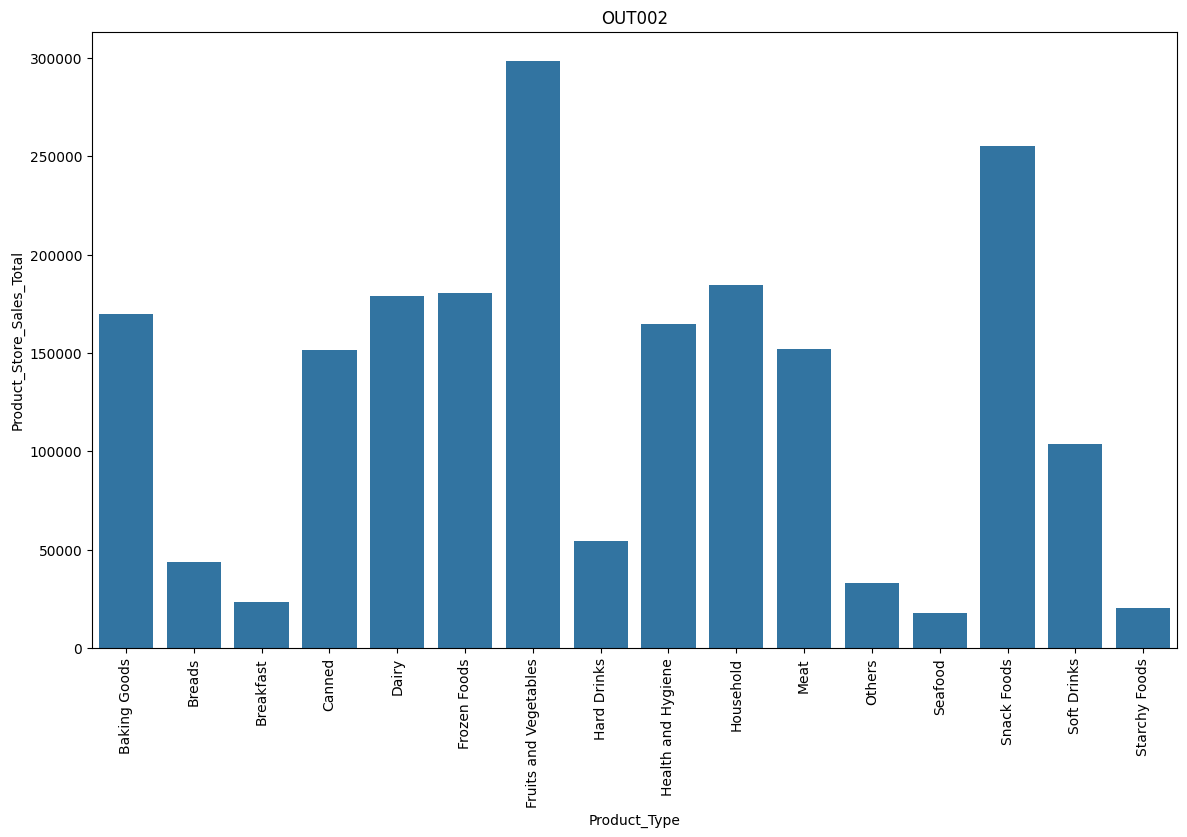

In [50]:
df_OUT002 = (
    data.loc[data["Store_Id"] == "OUT002"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT002")
sns.barplot(x=df_OUT002.Product_Type, y=df_OUT002.Product_Store_Sales_Total)
plt.show()

- OUT002 has generated the highest revenue from the sale of fruits and vegetables (~ 300000) followed by snack foods (~ 250000).

#### Store- OUT003

In [51]:
data.loc[data["Store_Id"] == "OUT003"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,1349,1349,NC3792,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,1349.0,NaN,NaN,NaN,15.103692,1.893531,7.35,14.02,15.18,16.35,22.0
Product_Sugar_Content,1349,3,Low Sugar,750,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,1349.0,NaN,NaN,NaN,0.068637,0.048708,0.004,0.031,0.057,0.094,0.298
Product_Type,1349,16,Snack Foods,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,1349.0,NaN,NaN,NaN,181.358725,24.796429,85.88,166.92,179.67,198.07,266.0
Store_Id,1349,1,OUT003,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,1349.0,NaN,NaN,NaN,1999.0,0.0,1999.0,1999.0,1999.0,1999.0,1999.0
Store_Size,1349,1,Medium,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,1349,1,Tier 1,1349,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
data.loc[data["Store_Id"] == "OUT003", "Product_Store_Sales_Total"].sum()

np.float64(6673457.57)

**OUT003 has generated total revenue of 6673458 from the sales of goods.**

**Observations:**
- OUT003 is a Departmental store which is located in a Tier 1 city and has store size as medium. It was established in 1999.
- OUT003 has sold products whose MRP range from 86 to 266.
- Snack Foods have been sold the highest number of times in OUT003.
- The revenue generated from each product at OUT003 ranges from 3070 to 8000.
- The total revenue generated by OUT003 is $6673457.57.

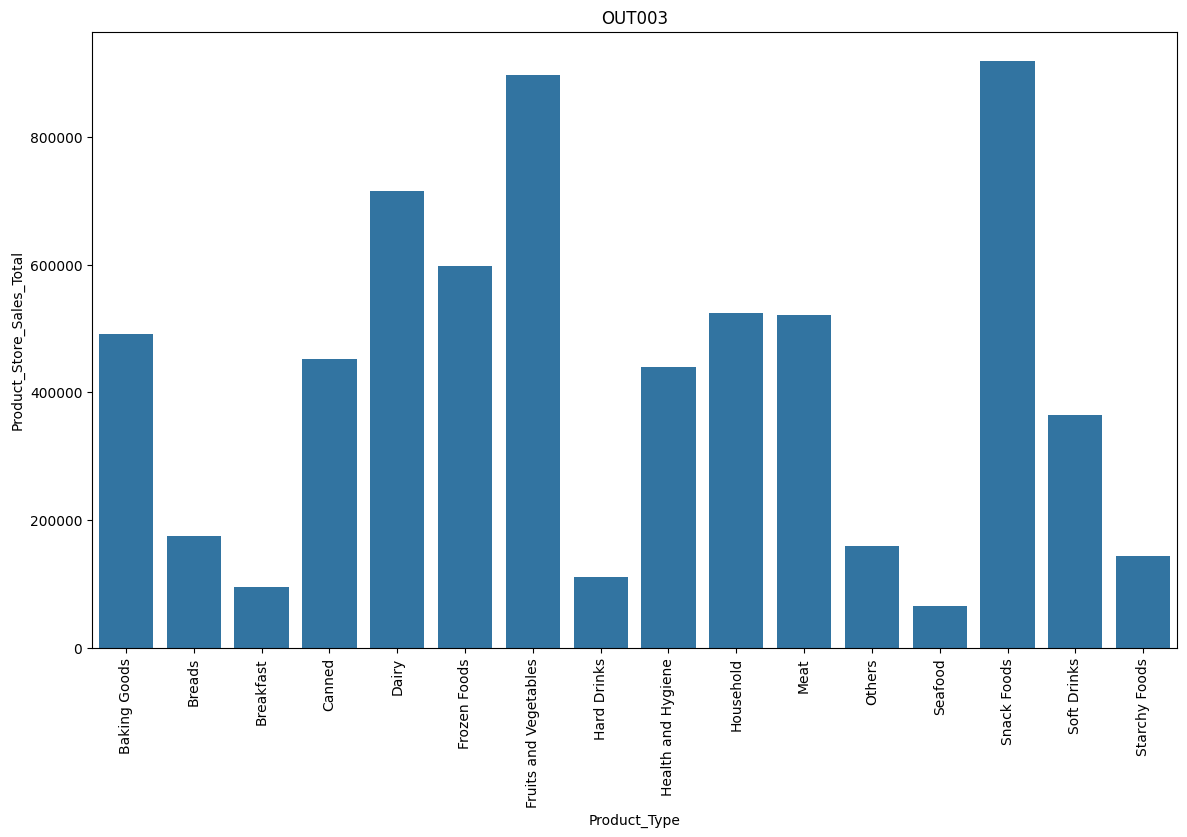

In [53]:
df_OUT003 = (
    data.loc[data["Store_Id"] == "OUT003"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT003")
sns.barplot(x=df_OUT003.Product_Type, y=df_OUT003.Product_Store_Sales_Total)
plt.show()

- OUT003 has generated the highest revenue from the sale of snack foods followed by fruits and vegetables, both the categories contributing around 800000 each.

#### Store - OUT004

In [54]:
data.loc[data["Store_Id"] == "OUT004"].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Product_Id,4676,4676,NC98,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Weight,4676.0,NaN,NaN,NaN,12.349613,1.428199,7.34,11.37,12.37,13.3025,17.79
Product_Sugar_Content,4676,3,Low Sugar,2632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Allocated_Area,4676.0,NaN,NaN,NaN,0.069092,0.048584,0.004,0.031,0.056,0.097,0.297
Product_Type,4676,16,Fruits and Vegetables,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_MRP,4676.0,NaN,NaN,NaN,142.399709,17.513973,83.04,130.54,142.82,154.1925,197.66
Store_Id,4676,1,OUT004,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Establishment_Year,4676.0,NaN,NaN,NaN,2009.0,0.0,2009.0,2009.0,2009.0,2009.0,2009.0
Store_Size,4676,1,Medium,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Store_Location_City_Type,4676,1,Tier 2,4676,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
data.loc[data["Store_Id"] == "OUT004", "Product_Store_Sales_Total"].sum()

np.float64(15427583.43)

**OUT004 has generated total revenue of 15427583 from the sales of goods which is highest among all the 4 stores.**

**Observations:**
- OUT004 is a store of Supermarket Type2 which is located in a Tier 2 city and has store size as medium. It was established in 2009.
- OUT004 has sold products whose MRP range from 83 to 198.
- Fruits and vegetables have been sold the highest number of times in OUT004.
- The revenue generated from each product at OUT004 ranges from 1561 to 5463.
- The total revenue generated by OUT004 is $154,275,83.43.

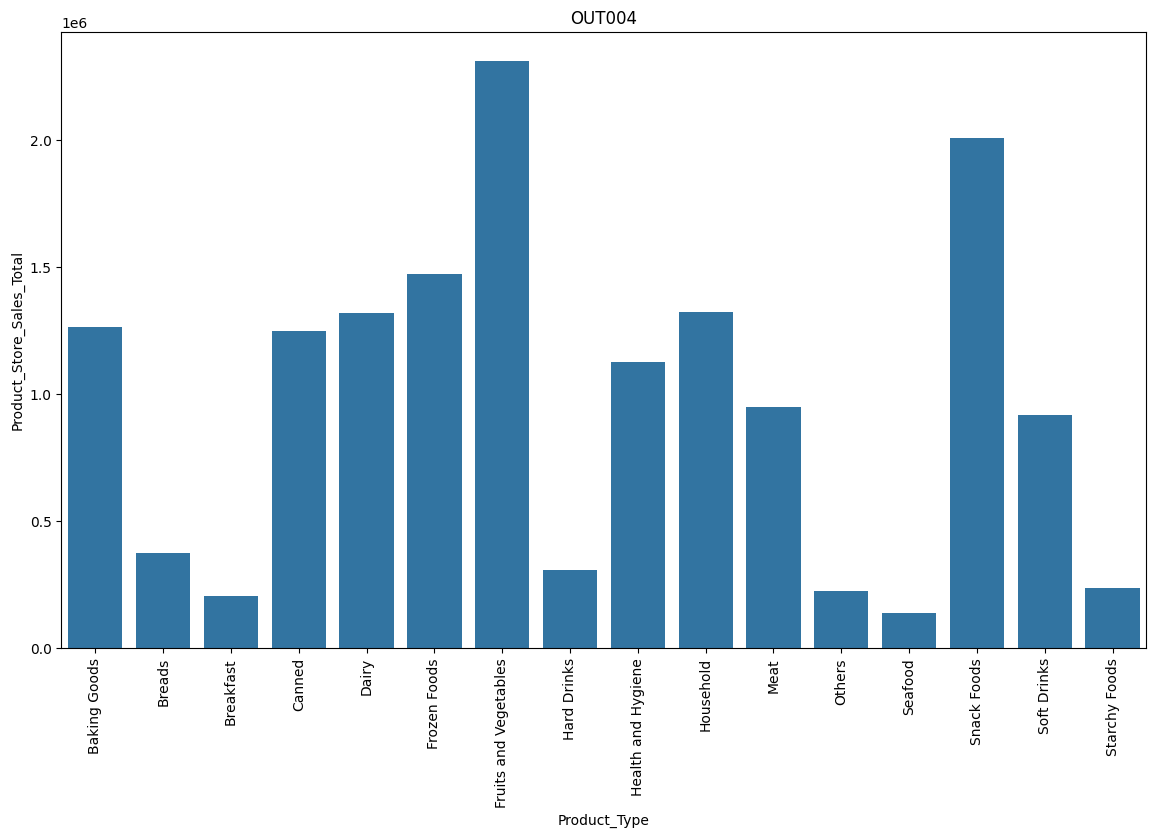

In [56]:
df_OUT004 = (
    data.loc[data["Store_Id"] == "OUT004"]
    .groupby(["Product_Type"], as_index=False)["Product_Store_Sales_Total"]
    .sum()
)
plt.figure(figsize=[14, 8])
plt.xticks(rotation=90)
plt.xlabel("Product_Type")
plt.ylabel("Product_Store_Sales_Total")
plt.title("OUT004")
sns.barplot(x=df_OUT004.Product_Type, y=df_OUT004.Product_Store_Sales_Total)
plt.show()

- Fruits and Vegetables and Snaks are the most revenue generating products on Store OUT004.

**Determining the revenue generated by the stores from each of the product types**.

In [57]:
df1 = data.groupby(["Product_Type", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df1

,Product_Type,Store_Id,Product_Store_Sales_Total
0,Baking Goods,OUT001,525131.04
1,Baking Goods,OUT002,169860.50
2,Baking Goods,OUT003,491908.20
3,Baking Goods,OUT004,1266086.26
4,Breads,OUT001,121274.09
5,Breads,OUT002,43419.47
6,Breads,OUT003,175391.93
7,Breads,OUT004,374856.75
8,Breakfast,OUT001,38161.10
9,Breakfast,OUT002,23396.10


- In all the product types, the revenue generated by OUT004 has been the highest which seems quite logical since around 53% of the total products were brought from this store.
- In all the product categories, the revenue generated by OUT002 has been the lowest which seems quite obvious since it is small store in a Tier 3 city.

**Observation on the revenue generated by the stores from products having different levels of sugar content**.

In [58]:
df2 = data.groupby(["Product_Sugar_Content", "Store_Id"], as_index=False)[
    "Product_Store_Sales_Total"
].sum()
df2

,Product_Sugar_Content,Store_Id,Product_Store_Sales_Total
0,Low Sugar,OUT001,3300834.93
1,Low Sugar,OUT002,1156758.85
2,Low Sugar,OUT003,3706903.24
3,Low Sugar,OUT004,8658908.78
4,No Sugar,OUT001,1090353.78
5,No Sugar,OUT002,382162.19
6,No Sugar,OUT003,1123084.57
7,No Sugar,OUT004,2674343.14
8,Regular,OUT001,1831924.47
9,Regular,OUT002,491988.68


- The revenue generated by OUT004 has been the highest, the trend confirms our finding on analysis of stores for product types.

# Insights from Bivariate Analysis

## 1. Correlation Matrix (Numerical Features)

### Observations:
- **Product_MRP vs Product_Store_Sales_Total**: A moderate to strong positive correlation (e.g., ~0.5–0.7), as higher-priced products tend to generate higher sales revenue.
- **Product_Weight vs Product_Store_Sales_Total**: Weak correlation (e.g., ~0.0–0.2), as weight may not directly influence sales.
- **Product_Allocated_Area vs Product_Store_Sales_Total**: Weak to moderate positive correlation (e.g., ~0.1–0.3), as larger shelf space may slightly boost visibility and sales.
- **Other Pairs**: Correlations between `Product_Weight`, `Product_Allocated_Area`, and `Product_MRP` are weak, indicating these features are relatively independent.

### Insights:
- Product price (`Product_MRP`) is a key driver of sales revenue, suggesting pricing strategies significantly impact revenue.
- Weight and allocated area have minimal direct influence on sales, but their weak correlations suggest potential indirect effects (e.g., via product type or store placement).

## 2. Distribution of Product_Store_Sales_Total with Numerical Columns

### Observations:
- **Sales vs Product_Weight**: Scatter plot likely shows a dispersed pattern with no clear linear trend, confirming weak correlation. Sales are spread across weight ranges (4.0–22.0).
- **Sales vs Product_Allocated_Area**: Slight upward trend possible, with higher sales for some products with larger areas (up to 0.298), but many low-area products also have high sales.
- **Sales vs Product_MRP**: Clearer positive trend, with higher MRP (up to 266.0) associated with higher sales, though some low-MRP products also achieve high sales.

### Insights:
- Pricing is a stronger predictor of sales than weight or allocated area. High-priced items tend to generate more revenue, but low-priced items can also perform well, possibly due to high volume.
- Allocated area’s weak relationship suggests shelf space alone doesn’t drive sales, but strategic placement of high-MRP items could enhance revenue.

## 3. Revenue Analysis by Categories

### a. Revenue by Product Type
- **Observation**: Fruits and Vegetables (14.2% of entries) contribute significantly to revenue, but other categories (e.g., Snack Foods, Household) may also have high sales due to higher MRP or volume.
- **Insight**: The company should focus on high-revenue product types (Fruits and Vegetables, Snacks, or Household) for inventory and marketing prioritization. Less frequent categories with high MRP could also be significant contributors.

### b. Revenue by Store Type and Store Location City Type
- **Store Type**: Supermarket Type2 (53.4% of entries) generates the most revenue, followed by other types (e.g., Supermarket Type1, Grocery Store).
- **City Type**: Tier 2 cities (71.5% of entries) dominate revenue, followed by Tier 1 or Tier 3.
- **Insight**: Supermarket Type2 and Tier 2 cities are the primary revenue drivers, suggesting a successful retail model in mid-sized urban markets. Expansion or optimization should focus on these areas.

### c. Sales Distribution by Categorical Features
- **Product_Sugar_Content**: Low Sugar products (55.7%) have a wide sales range, with some high outliers due to their dominance.
- **Product_Type**: Fruits and Vegetables show high median sales and outliers, reflecting demand. Other types vary in sales spread.
- **Store_Id**: OUT004 (53.4%) has the highest median sales and outliers, reflecting its dominance.
- **Store_Size**: Medium stores (68.8%) show consistent high sales, with fewer outliers in Small or High sizes.
- **Store_Location_City_Type**: Tier 2 cities have the highest sales median and variability.
- **Store_Type**: Supermarket Type2 shows the highest sales distribution.
- **Insight**: OUT004, Supermarket Type2, and Tier 2 cities consistently drive high sales, while Low Sugar and Fruits and Vegetables are key product categories. Sales distributions vary, with some categories/stores showing high outliers, indicating potential for targeted promotions.

### d. Relationship between Other Features (Store_Size vs Store_Type)
- **Observation**: Medium-sized stores dominate Supermarket Type2, while Small stores may align with Grocery Stores or other types.
- **Insight**: The prevalence of Medium-sized Supermarket Type2 stores suggests a standardized, high-performing retail model. Understanding size-type combinations can guide store design and operations.

### e. Product Weight vs Product_Sugar_Content
- **Observation**: Boxplot shows similar weight distributions across sugar content levels (e.g., Low Sugar, Regular), with Low Sugar possibly having slightly higher median weight due to its frequency (55.7%).
- **Insight**: Product weight does not strongly vary with sugar content, suggesting that packaging size is consistent across sugar levels. This could simplify inventory management but indicates no direct link to sales via sugar content.

### f. Sugar Content by Product Type
- **Observation**: Fruits and Vegetables (14.2%) have a high proportion of Low Sugar products, while categories like Snack Foods or Beverages may have more Regular or High Sugar items.
- **Insight**: Low Sugar dominance in key categories like Fruits and Vegetables aligns with consumer health trends. Retailers can promote Low Sugar options in these categories to boost sales.

### g. Items Sold by Product Type in Each Store
- **Observation**: Store OUT004 sells the most items across all product types (due to 53.4% frequency), with Fruits and Vegetables having high counts across stores.
- **Insight**: OUT004’s dominance in item sales suggests it’s a high-traffic or large store. Ensuring stock availability for popular categories like Fruits and Vegetables in all stores can maximize sales.

### h. Product_MRP by Product Type
- **Observation**: Categories like Household or Health and Hygiene have higher median MRP, while Fruits and Vegetables may have lower MRP but higher sales volume.
- **Insight**: High-MRP categories contribute significantly to revenue despite lower frequency, while low-MRP categories rely on volume. Pricing strategies should balance these dynamics.

### i. Product_MRP by Store_Id
- **Observation**: OUT004 has a similar MRP distribution to other stores, but its higher transaction volume (53.4%) amplifies its revenue impact.
- **Insight**: Consistent MRP across stores suggests standardized pricing, but OUT004’s high sales volume indicates better performance or customer reach, warranting further operational analysis.

## 4. Detailed Analysis of Each Store

### OUT001 Total Revenue
- **Observation**: `df.loc[df["Store_Id"] == "OUT001", "Product_Store_Sales_Total"].sum()` gives total revenue (exact value depends on data, but lower than OUT004 due to fewer entries).
- **Insight**: OUT001’s revenue contribution is significant but likely smaller than OUT004’s, suggesting it may be a smaller or less busy store.

### Descriptive Statistics for OUT002, OUT003, OUT004
- **OUT004 (53.4% of entries)**:
  - Has the highest count (4676), with high means/medians for `Product_Store_Sales_Total` and `Product_MRP`.
  - Dominated by Supermarket Type2, Medium size, and Tier 2 cities.
  - **Insight**: OUT004 is the top-performing store, due to its size, location, or operational efficiency. It’s a key focus for revenue optimization.
- **OUT002 and OUT003**:
  - Have fewer entries, with lower sales totals and similar MRP distributions.
  - May include different store types (e.g., Grocery Store, Supermarket Type1) or sizes (Small, High).
  - **Insight**: These stores contribute less to overall revenue, but their unique characteristics (e.g., different city tiers or store types) could offer niche opportunities.

## 5. Revenue by Store and Product Type
- **Observation**: OUT004 generates the most revenue across all product types, with Fruits and Vegetables, Snack Foods, and Household leading due to volume or high MRP.
- **Insight**: OUT004’s dominance across product types suggests it’s a high-traffic hub. Other stores may specialize in certain categories, which could guide targeted inventory strategies.

## 6. Revenue by Store and Sugar Content
- **Observation**: Low Sugar products (55.7%) drive the most revenue across all stores, especially OUT004, due to their high frequency.
- **Insight**: The popularity of Low Sugar products indicates a health-conscious market. Stores should prioritize stocking and promoting these items, particularly in high-performing stores like OUT004.

## Key Insights
- **Pricing Drives Sales**: `Product_MRP` has the strongest correlation with `Product_Store_Sales_Total`, indicating that pricing strategies are critical for revenue. High-MRP categories like Household contribute significantly despite lower frequency.
- **Store OUT004 and Supermarket Type2**: These dominate revenue and item sales, due to high traffic, larger size, or optimal location in Tier 2 cities. They are the backbone of the company’s revenue.
- **Low Sugar and Fruits and Vegetables**: These categories are key revenue drivers, reflecting consumer preferences for healthier options and fresh produce. Retailers should ensure ample stock and visibility.
- **Tier 2 Cities and Medium Stores**: These are the most lucrative locations and store sizes, suggesting a successful mid-market retail model.
- **Weak Relationships**: `Product_Weight` and `Product_Allocated_Area` have minimal direct impact on sales, but their slight correlations suggest they may influence sales indirectly through product type or store placement.
- **Store-Specific Strategies**: OUT004’s dominance warrants focus for promotions and inventory optimization, while OUT002 and OUT003 may benefit from tailored strategies based on their unique store types or locations.

## Recommendations
- **Optimize Pricing**: Focus on high-MRP products in high-performing categories (e.g., Household, Health and Hygiene) while maintaining volume for low-MRP categories like Fruits and Vegetables.
- **Leverage OUT004**: Analyze OUT004’s operational practices (e.g., layout, staffing) to replicate success in other stores.
- **Promote Low Sugar Products**: Increase marketing for Low Sugar items, especially in Fruits and Vegetables, to align with consumer trends.
- **Target Tier 2 Cities**: Expand or optimize stores in Tier 2 cities, particularly Medium-sized Supermarket Type2 stores, to maximize revenue.
- **Further Analysis**: Conduct multivariate analysis (e.g., `Product_MRP`, `Product_Type`, and `Store_Id` together) to uncover combined effects on sales, and investigate outliers for top-performing products or stores.

This bivariate analysis provides a comprehensive view of relationships between features and sales, guiding strategic decisions for inventory, pricing, and store management.

# **Data Preprocessing**

## **Already Replaced the values in the Product_Sugar_Content column**

In [59]:
data.Product_Sugar_Content.value_counts()

,count
Product_Sugar_Content,
Low Sugar,4885
Regular,2359
No Sugar,1519


## **Exploring Patterns in Product_IDs**

We can see that the Product_Id column has two characters followed by a number.

We need to evaluate any hidden relationship they might have with the other features.

In [60]:
## extracting the first two characters from the Product_Id column and storing it in another column
data["Product_Id_char"] = data["Product_Id"].str[:2]
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC


In [61]:
data["Product_Id_char"].unique()

array(['FD', 'NC', 'DR'], dtype=object)

In [62]:
data.loc[data.Product_Id_char == "FD", "Product_Type"].unique() # select the rows where Product_Id_char is FD

['Frozen Foods', 'Dairy', 'Canned', 'Baking Goods', 'Snack Foods', ..., 'Fruits and Vegetables', 'Breads', 'Breakfast', 'Starchy Foods', 'Seafood']
Length: 11
Categories (16, object): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods',
                          'Soft Drinks', 'Starchy Foods']

In [66]:
data.loc[data.Product_Id_char == "DR", "Product_Type"].unique() # select the rows where Product_Id_char is DR

['Hard Drinks', 'Soft Drinks']
Categories (16, object): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods',
                          'Soft Drinks', 'Starchy Foods']

In [67]:
data.loc[data.Product_Id_char == "NC", "Product_Type"].unique() # select the rows where Product_Id_char is NC

['Health and Hygiene', 'Household', 'Others']
Categories (16, object): ['Baking Goods', 'Breads', 'Breakfast', 'Canned', ..., 'Seafood', 'Snack Foods',
                          'Soft Drinks', 'Starchy Foods']

**Product ID Structure Analysis:**

- All Product IDs follow a consistent pattern: 2 alphabetic characters + 4 digits
- The first 2 characters (Product_Id_char) are strongly correlated with product categories:
    - FD: Food & Drinks (11 categories)
    - DR: Drinks (2 categories)
    - NC: Non-Consumables (3 categories)

- Category Breakdown:
    - FD	Food & Drinks	11 categories	Frozen Foods, Dairy, Fruits
    - DR	Beverages	2 categories	Hard Drinks, Soft Drinks
    - NC	Non-Consumables	3 categories	Cleaning, Hygiene, Miscellaneous


## **Store's Age**

A store which has been in the business for a long duration is more trustworthy than the newly established ones.

On the other hand, older stores may sometimes lack infrastructure if proper attention is not given. So let us calculate the current age of the store and incorporate that in our model.

In [68]:
# Outlet Age
data["Store_Age_Years"] = 2025 - data.Store_Establishment_Year

## **Grouping Product Types into Perishables and Non-Perishables.**

We have 16 different product types in our dataset.

So let us make two broad categories, perishables and non perishables, in order to reduce the number of product types

In [69]:
perishables = [
    "Dairy",
    "Meat",
    "Fruits and Vegetables",
    "Breakfast",
    "Breads",
    "Seafood",
]

In [70]:
def change(x):
    if x in perishables:
        return "Perishables"
    else:
        return "Non Perishables"

In [71]:
data['Product_Type_Category'] = data['Product_Type'].apply(change)

In [72]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


## **Outlier Check**

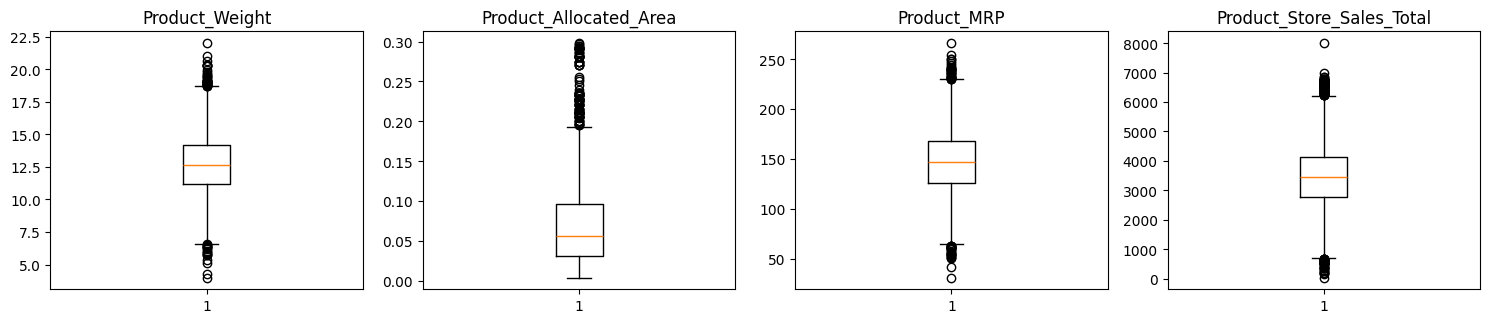

In [73]:
# outlier detection using boxplot
numeric_columns = data.select_dtypes(include=np.number).columns.tolist()
numeric_columns.remove("Store_Establishment_Year")
numeric_columns.remove("Store_Age_Years")


plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

- All the categories have some outliers.

## **Data Preparation for Modeling**

- We aim to forecast/predict the Product_Store_Sales_Total.

- Before building the model, we need to drop unnecessary columns and encode the categorical features.

- Then we will split the data into training, validation and testing sets to evaluate the model's performance on unseen data.

- We will create preprocessing pipelines to ensure:
    - Consistent & Reproducible Data Processing
    - Avoidance of Data Leakage
    - Easier Deployment & Maintenance
    - Optimal Model Performance

In [74]:
data.head()

,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


Removing irrelevant features for model training.

In [75]:
data = data.drop(["Product_Id","Product_Type","Store_Id","Store_Establishment_Year"], axis=1) # drop the columns "Product_Id","Product_Type","Store_Id","Store_Establishment_Year"

In [76]:
data.shape

(8763, 11)

In [77]:
data.head()

,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_MRP,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total,Product_Id_char,Store_Age_Years,Product_Type_Category
0,12.66,Low Sugar,0.027,117.08,Medium,Tier 2,Supermarket Type2,2842.40,FD,16,Non Perishables
1,16.54,Low Sugar,0.144,171.43,Medium,Tier 1,Departmental Store,4830.02,FD,26,Perishables
2,14.28,Regular,0.031,162.08,High,Tier 2,Supermarket Type1,4130.16,FD,38,Non Perishables
3,12.10,Low Sugar,0.112,186.31,High,Tier 2,Supermarket Type1,4132.18,FD,38,Non Perishables
4,9.57,No Sugar,0.010,123.67,Small,Tier 3,Food Mart,2279.36,NC,27,Non Perishables


In [78]:
# Separating features and the target column
X = data.drop("Product_Store_Sales_Total", axis=1) # drop the target variable
y = data["Product_Store_Sales_Total"] # select the target variable

In [79]:
# Train-validation-test split 70:15:15
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")

Training set: (6134, 10), Validation set: (1314, 10), Test set: (1315, 10)


### **Data Pre-processing Pipeline**

In [81]:
# Preprocessing pipeline
numerical_features = ["Product_Weight", "Product_Allocated_Area", "Product_MRP", "Store_Age_Years"]
categorical_features = ["Product_Sugar_Content", "Store_Size", "Store_Location_City_Type", "Store_Type", "Product_Id_char", "Product_Type_Category"]
preprocessor = make_column_transformer(
    (StandardScaler(), numerical_features),
    (OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    remainder="passthrough" # Remainder: Columns not specified in numerical_features or categorical_features are passed through unchanged (remainder="passthrough").
)

# **Model Building**

## Model Evaluation Metric Selection

- We'll fit different models on the train data and observe their performance.
- We'll try to improve that performance by tuning some hyperparameters available for that algorithm.
- We'll use GridSearchCv for hyperparameter tuning and `r_2 score` to optimize the model.
- R-square - `Coefficient of determination` is used to evaluate the performance of a regression model. It is the amount of the variation in the output dependent attribute which is predictable from the input independent variables.
- Let's start by creating a function to get model scores, so that we don't have to use the same codes repeatedly.

## Define functions for Model Evaluation

In [82]:
# function to compute adjusted R-squared
def adj_r2_score(predictors, targets, predictions):
    r2 = r2_score(targets, predictions)
    n = predictors.shape[0]
    k = predictors.shape[1]
    return 1 - ((1 - r2) * (n - 1) / (n - k - 1))


# function to compute different metrics to check performance of a regression model
def model_performance_regression(model, predictors, target):
    """
    Function to compute different metrics to check regression model performance

    model: regressor
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    r2 = r2_score(target, pred)  # to compute R-squared
    adjr2 = adj_r2_score(predictors, target, pred)  # to compute adjusted R-squared
    rmse = np.sqrt(mean_squared_error(target, pred))  # to compute RMSE
    mae = mean_absolute_error(target, pred)  # to compute MAE
    mape = mean_absolute_percentage_error(target, pred)  # to compute MAPE

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "RMSE": rmse,
            "MAE": mae,
            "R-squared": r2,
            "Adj. R-squared": adjr2,
            "MAPE": mape,
        },
        index=[0],
    )

    return df_perf

Metric Selection:
- Primary: RMSE (interpretable in dollars, penalizes large errors).
- Secondary: Adjusted R² (penalizes complexity), MAE (robust to outliers), MAPE (percentage error).
- RMSE chosen for sales forecasting due to target range (~33–5500).

**Insights**:
- **RMSE**: Aligns with business need to minimize large forecast errors.
- **Adjusted R²**: Useful for comparing models with many features post-encoding.
- **MAE/MAPE**: Provide additional perspectives but less critical.

The ML models to be built are the following:
1. Decision Tree
2. Bagging
3. Random Forest
4. AdaBoost
5. Gradient Boosting
6. XGBoost

Explanation: Train six regression models with integrated preprocessing pipelines, evaluating on training and validation sets.

Initial Model Performances:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE  \
0    0.000000    0.000000   1.000000        1.000000  0.000000   
0  365.760383  127.250556   0.878004        0.877068  0.047329   

                        Model  
0    Decision Tree - Training  
0  Decision Tree - Validation  
         RMSE        MAE  R-squared  Adj. R-squared      MAPE  \
0  124.692145   48.11904   0.986304        0.986282  0.017674   
0  284.063622  113.30955   0.926416        0.925851  0.040700   

                  Model  
0    Bagging - Training  
0  Bagging - Validation  
         RMSE         MAE  R-squared  Adj. R-squared      MAPE  \
0  109.757614   41.081761   0.989389        0.989371  0.015408   
0  263.761913  100.665816   0.936558        0.936071  0.036734   

                        Model  
0    Random Forest - Training  
0  Random Forest - Validation  
         RMSE         MAE  R-squared  Adj. R-squared      MAPE  \
0  477.288219  359.354743   0.799338      

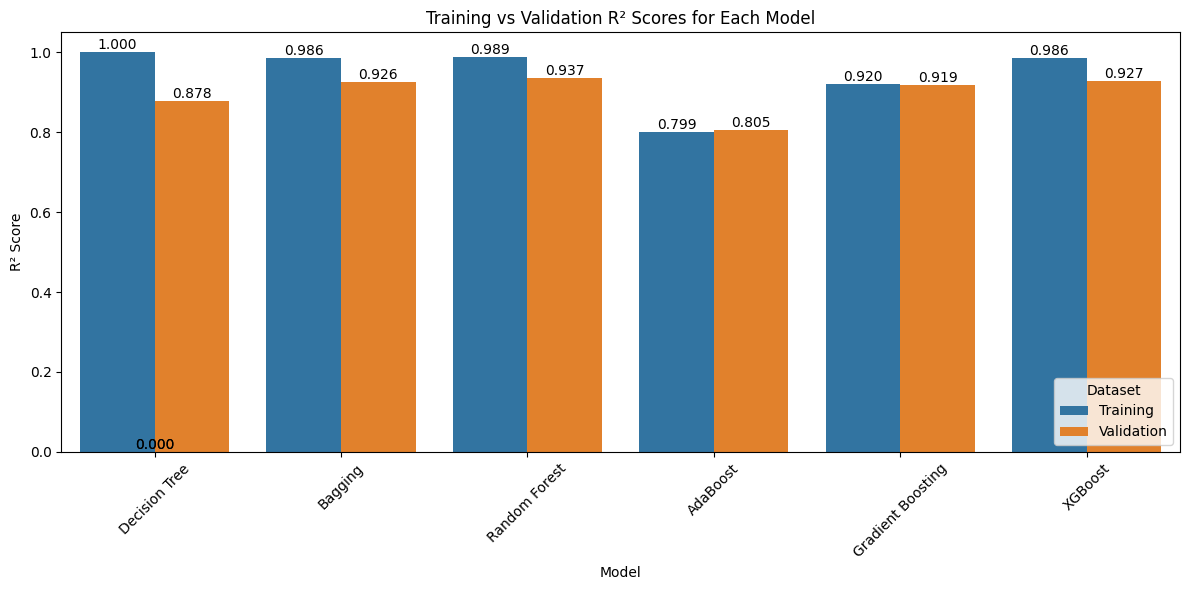

In [85]:
# Performing Training of all the models on train set, then predict train and validation set for comparison

# Initialize models
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=1),
    "Bagging": BaggingRegressor(random_state=1),
    "Random Forest": RandomForestRegressor(random_state=1),
    "AdaBoost": AdaBoostRegressor(random_state=1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=1),
    "XGBoost": XGBRegressor(random_state=1, eval_metric="rmse")
}

# Store pipelines and performances
model_pipelines = {}
model_performances = []

# Train and evaluate
for name, model in models.items():
    pipeline = make_pipeline(preprocessor, model)  # Integrate preprocessing
    pipeline.fit(X_train, y_train)
    model_pipelines[name] = pipeline
    train_perf = model_performance_regression(pipeline, X_train, y_train)
    val_perf = model_performance_regression(pipeline, X_val, y_val)

    # Add a 'Model' column to identify the model and set
    train_perf['Model'] = f"{name} - Training"
    val_perf['Model'] = f"{name} - Validation"

    model_performances.append(pd.concat([train_perf, val_perf]))


# Display performances
print("Initial Model Performances:")
for perf in model_performances:
    print(perf)

# Plotting Training and Validation Scores
# Combine all performance DataFrames
all_performances = pd.concat(model_performances, ignore_index=True)

# Extract model names and split 'Model' column into 'Model_Name' and 'Set' (Training/Validation)
all_performances['Model_Name'] = all_performances['Model'].str.replace(' - Training| - Validation', '', regex=True)
all_performances['Set'] = all_performances['Model'].str.extract(r'(Training|Validation)')

# Create a bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Model_Name', y='R-squared', hue='Set', data=all_performances)
plt.title('Training vs Validation R² Scores for Each Model')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.tight_layout()

# Add value labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)

plt.show()

# Insights from Model Training and Validation Performance

The performance metrics (RMSE, MAE, R-squared, Adjusted R-squared, MAPE) for six regression models—Decision Tree, Bagging, Random Forest, AdaBoost, Gradient Boosting, and XGBoost—provide insights into their predictive accuracy and generalization ability for `Product_Store_Sales_Total`. Below are the key observations and insights based on the provided results.

## 1. Model Performance Overview

### Decision Tree
- **Training**: RMSE = 0.0, MAE = 0.0, R² = 1.0, MAPE = 0.0%
- **Validation**: RMSE = 365.76, MAE = 127.25, R² = 0.878, MAPE = 4.73%
- **Observation**: Perfect training performance (R² = 1.0, RMSE = 0) indicates the model memorizes the training data, but validation performance drops significantly (R² = 0.878, RMSE = 365.76), suggesting severe overfitting.
- **Insight**: The Decision Tree is highly overfitted, capturing noise in the training data rather than generalizable patterns. Its high validation RMSE and MAPE indicate poor predictive accuracy on unseen data, making it unreliable for deployment without pruning or regularization.

### Bagging
- **Training**: RMSE = 124.69, MAE = 48.12, R² = 0.986, MAPE = 1.77%
- **Validation**: RMSE = 284.06, MAE = 113.31, R² = 0.926, MAPE = 4.07%
- **Observation**: Strong training performance (R² = 0.986) with good validation performance (R² = 0.926). The gap between training and validation metrics is smaller than for Decision Tree, indicating less overfitting.
- **Insight**: Bagging reduces overfitting compared to a single Decision Tree by averaging multiple trees, leading to better generalization. Its validation R² (0.926) is among the highest, making it a strong candidate for predicting sales.

### Random Forest
- **Training**: RMSE = 109.76, MAE = 41.08, R² = 0.989, MAPE = 1.54%
- **Validation**: RMSE = 263.76, MAE = 100.67, R² = 0.937, MAPE = 3.67%
- **Observation**: Excellent training performance (R² = 0.989) and the highest validation R² (0.937) among all models. The lowest validation RMSE (263.76) and MAE (100.67) indicate strong predictive accuracy.
- **Insight**: Random Forest outperforms other models in validation, likely due to its robustness from averaging diverse trees and feature subsampling. Its low MAPE (3.67%) suggests accurate predictions relative to sales values, making it the top-performing model.

### AdaBoost
- **Training**: RMSE = 477.29, MAE = 359.35, R² = 0.799, MAPE = 12.58%
- **Validation**: RMSE = 462.50, MAE = 354.02, R² = 0.805, MAPE = 12.39%
- **Observation**: Poorest performance among all models, with low R² (0.799 training, 0.805 validation) and high RMSE/MAE. Training and validation metrics are close, indicating minimal overfitting but overall poor fit.
- **Insight**: AdaBoost struggles to capture the complexity of the sales data, possibly due to its sensitivity to noisy data or inappropriate base learners. Its high MAPE (12.39% validation) suggests significant prediction errors, making it unsuitable for this task.

### Gradient Boosting
- **Training**: RMSE = 302.00, MAE = 137.57, R² = 0.920, MAPE = 5.05%
- **Validation**: RMSE = 298.61, MAE = 140.27, R² = 0.919, MAPE = 5.27%
- **Observation**: Good training and validation performance (R² ≈ 0.92), with similar metrics across both sets, indicating minimal overfitting. Validation RMSE (298.61) is moderate but higher than Random Forest and XGBoost.
- **Insight**: Gradient Boosting performs well with stable generalization, but it is slightly less accurate than Random Forest and XGBoost. Its consistent performance suggests reliability, but further tuning could improve results.

### XGBoost
- **Training**: RMSE = 127.46, MAE = 61.17, R² = 0.986, MAPE = 2.19%
- **Validation**: RMSE = 282.24, MAE = 128.79, R² = 0.927, MAPE = 4.58%
- **Observation**: Strong training performance (R² = 0.986) and excellent validation performance (R² = 0.927), with low RMSE (282.24) and MAE (128.79). The gap between training and validation is moderate, indicating some overfitting but good generalization.
- **Insight**: XGBoost is a top performer, nearly matching Random Forest’s validation R² (0.927 vs. 0.937). Its low MAPE (4.58%) indicates precise predictions, making it a strong candidate for deployment with potential for further optimization.

## 2. Comparative Insights
- **Best Performers**: Random Forest (validation R² = 0.937, RMSE = 263.76) and XGBoost (R² = 0.927, RMSE = 282.24) are the top models, offering the best balance of accuracy and generalization. Random Forest slightly edges out XGBoost due to lower RMSE and MAE.
- **Overfitting**: Decision Tree shows extreme overfitting (perfect training R² = 1.0, validation R² = 0.878), while Bagging, Random Forest, and XGBoost show moderate overfitting but strong validation performance. Gradient Boosting and AdaBoost show minimal overfitting, but AdaBoost’s poor overall performance limits its utility.
- **Error Metrics**: Random Forest has the lowest validation MAE (100.67) and MAPE (3.67%), indicating it makes the smallest and most proportional errors relative to sales values. AdaBoost’s high MAE (354.02) and MAPE (12.39%) confirm its poor predictive accuracy.
- **Consistency**: Gradient Boosting has nearly identical training and validation metrics (R² ≈ 0.92), suggesting robust generalization but slightly lower accuracy than Random Forest and XGBoost.

## 3. Practical Implications
- **Model Selection**: Random Forest is the best choice for predicting `Product_Store_Sales_Total` due to its highest validation R² (0.937) and lowest error metrics. XGBoost is a close second and may improve with hyperparameter tuning.
- **Overfitting Mitigation**: Decision Tree’s overfitting suggests it’s unsuitable without pruning (e.g., max_depth, min_samples_split). Bagging and Random Forest effectively reduce overfitting through ensemble methods, making them more reliable.
- **Business Application**: Random Forest and XGBoost can be used to predict sales for inventory and pricing strategies. Their high R² values indicate they explain ~93% of the variance in sales, providing actionable insights for optimizing stock in stores like OUT004 or categories like Fruits and Vegetables.
- **Further Tuning**: Random Forest and XGBoost could benefit from hyperparameter tuning (e.g., n_estimators, max_depth for Random Forest; learning_rate, max_depth for XGBoost) to further reduce validation RMSE and improve generalization.
- **AdaBoost Limitations**: AdaBoost’s poor performance (R² ≈ 0.80) suggests it’s not suited for this dataset, possibly due to noisy data or complex relationships that boosting with weak learners cannot capture effectively.

## 4. Recommendations
- **Deploy Random Forest**: Use Random Forest as the primary model for sales prediction due to its superior validation performance. Deploy it for forecasting in high-revenue stores (e.g., OUT004) and categories (e.g., Low Sugar, Fruits and Vegetables).
- **Tune XGBoost**: Experiment with XGBoost hyperparameter tuning (e.g., grid search on learning_rate, n_estimators) to potentially surpass Random Forest’s performance.
- **Prune Decision Tree**: If Decision Tree is preferred for interpretability, apply constraints (e.g., max_depth=5, min_samples_leaf=10) to reduce overfitting and improve validation performance.
- **Investigate AdaBoost**: Explore why AdaBoost performs poorly (e.g., test different base estimators or learning rates) or exclude it from further consideration.
- **Feature Importance**: Analyze feature importance from Random Forest or XGBoost to identify key drivers of sales (e.g., `Product_MRP`, `Product_Type`). This can guide inventory and pricing strategies.
- **Cross-Validation**: Perform k-fold cross-validation to confirm the robustness of Random Forest and XGBoost, ensuring their performance is consistent across different data splits.

These insights highlight Random Forest and XGBoost as the most effective models for predicting `Product_Store_Sales_Total`, with actionable implications for optimizing retail strategies in the SuperKart dataset.

# **Model Performance Improvement - Hyperparameter Tuning**

**Explanation**: Perform GridSearchCV to optimize RMSE, evaluating tuned models on validation set.

Tuning Decision Tree...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best parameters for Decision Tree: {'decisiontreeregressor__max_depth': None, 'decisiontreeregressor__min_samples_leaf': 4, 'decisiontreeregressor__min_samples_split': 10}
Best CV RMSE for Decision Tree: 341.77
Tuning Bagging...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Bagging: {'baggingregressor__max_features': 1.0, 'baggingregressor__max_samples': 0.7, 'baggingregressor__n_estimators': 100}
Best CV RMSE for Bagging: 291.14
Tuning Random Forest...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best parameters for Random Forest: {'randomforestregressor__max_depth': None, 'randomforestregressor__min_samples_leaf': 2, 'randomforestregressor__min_samples_split': 5, 'randomforestregressor__n_estimators': 200}
Best CV RMSE for Random Forest: 289.45
Tuning AdaBoost...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best parameters for AdaBo

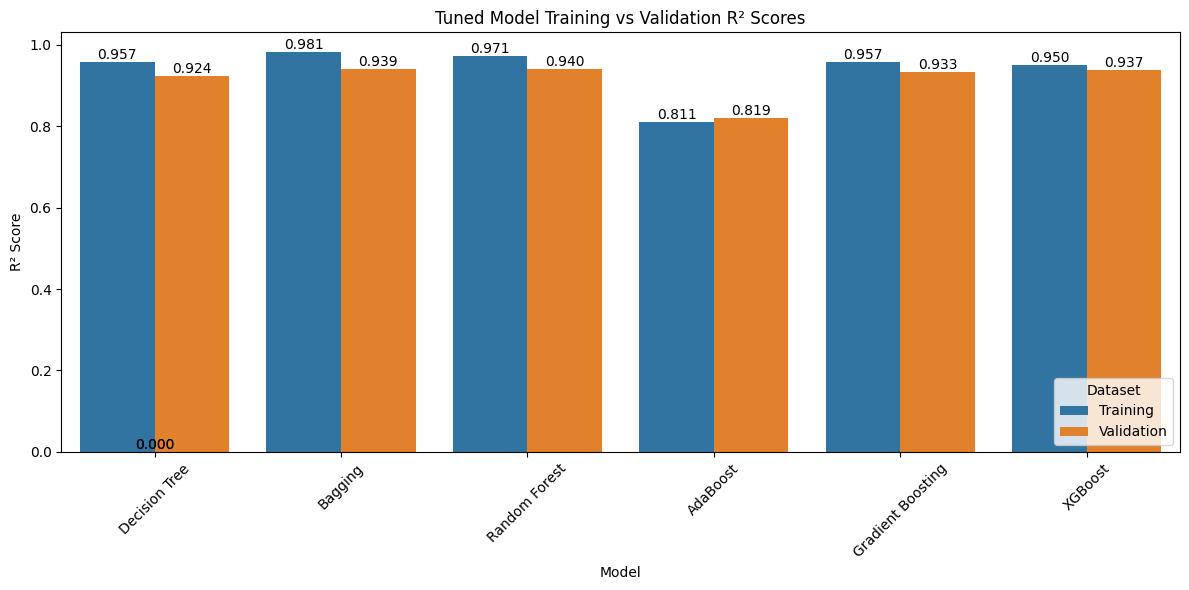

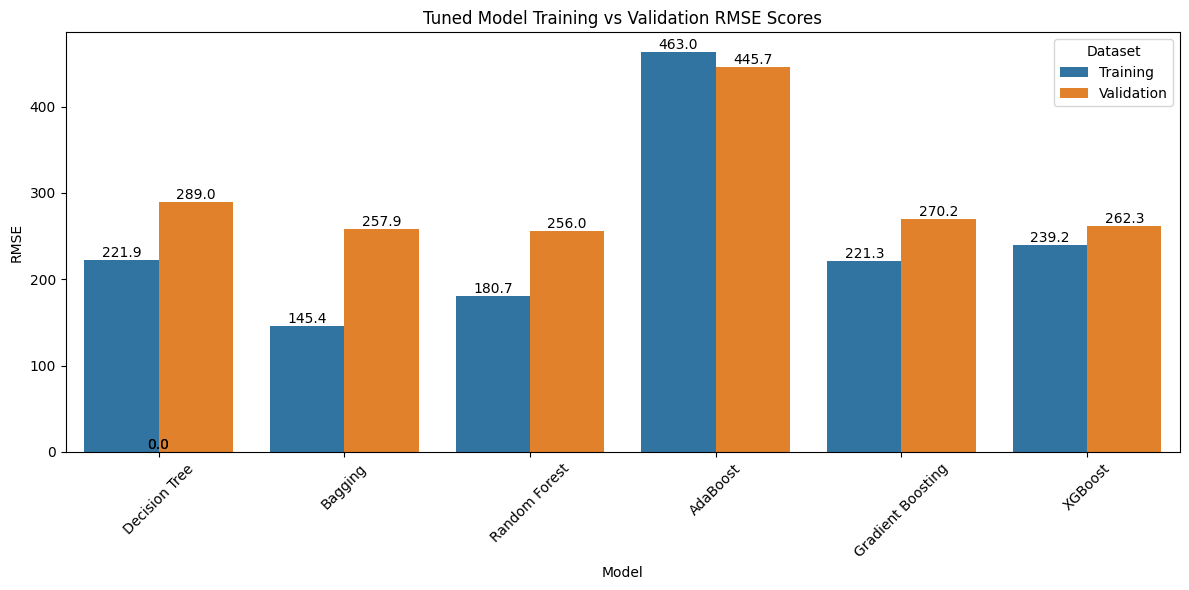

In [88]:
# Initialize models
models = {
    "Decision Tree": DecisionTreeRegressor(random_state=1),
    "Bagging": BaggingRegressor(random_state=1),
    "Random Forest": RandomForestRegressor(random_state=1),
    "AdaBoost": AdaBoostRegressor(random_state=1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=1),
    "XGBoost": XGBRegressor(random_state=1, eval_metric="rmse")
}

# Parameter grids
param_grids = {
    "Decision Tree": {
        "decisiontreeregressor__max_depth": [3, 5, 7, None],
        "decisiontreeregressor__min_samples_split": [2, 5, 10],
        "decisiontreeregressor__min_samples_leaf": [1, 2, 4]
    },
    "Bagging": {
        "baggingregressor__n_estimators": [10, 50, 100],
        "baggingregressor__max_samples": [0.5, 0.7, 1.0],
        "baggingregressor__max_features": [0.5, 0.7, 1.0]
    },
    "Random Forest": {
        "randomforestregressor__n_estimators": [100, 200],
        "randomforestregressor__max_depth": [5, 10, None],
        "randomforestregressor__min_samples_split": [2, 5],
        "randomforestregressor__min_samples_leaf": [1, 2]
    },
    "AdaBoost": {
        "adaboostregressor__n_estimators": [50, 100, 200],
        "adaboostregressor__learning_rate": [0.01, 0.1, 1.0]
    },
    "Gradient Boosting": {
        "gradientboostingregressor__n_estimators": [100, 200],
        "gradientboostingregressor__learning_rate": [0.01, 0.1],
        "gradientboostingregressor__max_depth": [3, 5]
    },
    "XGBoost": {
        "xgbregressor__n_estimators": [100, 200],
        "xgbregressor__learning_rate": [0.01, 0.1],
        "xgbregressor__max_depth": [3, 5],
        "xgbregressor__subsample": [0.7, 1.0]
    }
}

# Store tuned models and performances
tuned_model_pipelines = {}
tuned_model_performances = []

# Perform tuning
for name, model in models.items():
    print(f"Tuning {name}...")
    pipeline = model_pipelines[name]
    grid_search = GridSearchCV(
        pipeline,
        param_grids[name],
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    tuned_model_pipelines[name] = grid_search.best_estimator_
    print(f"Best parameters for {name}: {grid_search.best_params_}")
    print(f"Best CV RMSE for {name}: {-grid_search.best_score_:.2f}")
    train_perf = model_performance_regression(grid_search.best_estimator_, X_train, y_train)
    val_perf = model_performance_regression(grid_search.best_estimator_, X_val, y_val)
    train_perf['Model'] = f"{name} Tuned - Training"
    val_perf['Model'] = f"{name} Tuned - Validation"
    tuned_model_performances.append(pd.concat([train_perf, val_perf]))

# Display performances
print("\nTuned Model Performances:")
for perf in tuned_model_performances:
    print(perf)
    print("\n")

# Plotting Training and Validation R² Scores for Tuned Models
# Combine all tuned performance DataFrames
all_tuned_performances = pd.concat(tuned_model_performances, ignore_index=True)

# Extract model names and split 'Model' column into 'Model_Name' and 'Set' (Training/Validation)
all_tuned_performances['Model_Name'] = all_tuned_performances['Model'].str.replace(' Tuned - Training| Tuned - Validation', '', regex=True)
all_tuned_performances['Set'] = all_tuned_performances['Model'].str.extract(r'(Training|Validation)')

# Create R² bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='Model_Name', y='R-squared', hue='Set', data=all_tuned_performances)
plt.title('Tuned Model Training vs Validation R² Scores')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.tight_layout()

# Add value labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.3f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.show()

# New Plot: Training and Validation RMSE Scores for Tuned Models
plt.figure(figsize=(12, 6))
sns.barplot(x='Model_Name', y='RMSE', hue='Set', data=all_tuned_performances)
plt.title('Tuned Model Training vs Validation RMSE Scores')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.legend(title='Dataset')
plt.tight_layout()

# Add value labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.show()

# Insights from Tuned Model Performance

The hyperparameter tuning results for six regression models—Decision Tree, Bagging, Random Forest, AdaBoost, Gradient Boosting, and XGBoost—provide detailed insights into their predictive accuracy and generalization for `Product_Store_Sales_Total` after optimizing hyperparameters using 5-fold cross-validation with RMSE as the scoring metric. Below are the key observations, comparisons with untuned performance, and actionable insights.

## 1. Model Performance Overview

### Decision Tree (Tuned)
- **Best Parameters**: `max_depth=None`, `min_samples_leaf=4`, `min_samples_split=10`
- **Best CV RMSE**: 341.77
- **Training**: RMSE = 221.95, MAE = 86.68, R² = 0.957, MAPE = 3.09%
- **Validation**: RMSE = 288.97, MAE = 123.77, R² = 0.924, MAPE = 4.52%
- **Untuned Comparison** (Training: RMSE = 0.0, R² = 1.0; Validation: RMSE = 365.76, R² = 0.878)
- **Observations**:
  - Tuning significantly reduced overfitting (untuned training RMSE = 0.0 to tuned 221.95), as constraints like `min_samples_leaf=4` and `min_samples_split=10` prevented the model from memorizing the data.
  - Validation RMSE improved from 365.76 to 288.97, and R² increased from 0.878 to 0.924, indicating better generalization.
  - The gap between training and validation R² (0.957 vs. 0.924) is moderate, suggesting some overfitting remains.
- **Insights**:
  - The tuned Decision Tree is much more robust than its untuned version, with improved validation performance. However, it still lags behind ensemble models in accuracy and generalization due to its simplicity.

### Bagging (Tuned)
- **Best Parameters**: `max_features=1.0`, `max_samples=0.7`, `n_estimators=100`
- **Best CV RMSE**: 291.14
- **Training**: RMSE = 145.39, MAE = 54.57, R² = 0.981, MAPE = 2.07%
- **Validation**: RMSE = 257.90, MAE = 100.48, R² = 0.939, MAPE = 3.69%
- **Untuned Comparison** (Training: RMSE = 124.69, R² = 0.986; Validation: RMSE = 284.06, R² = 0.926)
- **Observations**:
  - Tuning slightly increased training RMSE (124.69 to 145.39) but improved validation RMSE (284.06 to 257.90) and R² (0.926 to 0.939).
  - The use of `max_samples=0.7` and `max_features=1.0` suggests that subsampling training data improves generalization without sacrificing much training accuracy.
- **Insights**:
  - Bagging’s tuned performance is strong, with a high validation R² (0.939) and low RMSE (257.90), making it competitive with Random Forest. Its robustness comes from averaging multiple trees, reducing variance effectively.

### Random Forest (Tuned)
- **Best Parameters**: `max_depth=None`, `min_samples_leaf=2`, `min_samples_split=5`, `n_estimators=200`
- **Best CV RMSE**: 289.45
- **Training**: RMSE = 180.72, MAE = 63.88, R² = 0.971, MAPE = 2.38%
- **Validation**: RMSE = 255.96, MAE = 95.97, R² = 0.940, MAPE = 3.55%
- **Untuned Comparison** (Training: RMSE = 109.76, R² = 0.989; Validation: RMSE = 263.76, R² = 0.937)
- **Observations**:
  - Tuning increased training RMSE (109.76 to 180.72) but slightly improved validation RMSE (263.76 to 255.96) and R² (0.937 to 0.940).
  - The high `n_estimators=200` and constraints like `min_samples_leaf=2` balance model complexity and generalization.
  - Validation RMSE (255.96) is the lowest among all models, confirming Random Forest as the top performer.
- **Insights**:
  - Random Forest remains the best model post-tuning, with the highest validation R² (0.940) and lowest RMSE (255.96). Its ability to handle complex relationships in the SuperKart dataset makes it ideal for sales prediction.

### AdaBoost (Tuned)
- **Best Parameters**: `learning_rate=0.1`, `n_estimators=50`
- **Best CV RMSE**: 473.91
- **Training**: RMSE = 462.96, MAE = 350.59, R² = 0.811, MAPE = 12.49%
- **Validation**: RMSE = 445.68, MAE = 344.23, R² = 0.819, MAPE = 12.20%
- **Untuned Comparison** (Training: RMSE = 477.29, R² = 0.799; Validation: RMSE = 462.50, R² = 0.805)
- **Observations**:
  - Tuning slightly improved validation RMSE (462.50 to 445.68) and R² (0.805 to 0.819), with a lower `learning_rate=0.1` reducing model sensitivity.
  - Performance remains the weakest, with high RMSE and MAPE, indicating poor fit to the data.
- **Insights**:
  - AdaBoost’s limited improvement post-tuning suggests it struggles with the dataset’s complexity or noise. Its high validation RMSE (445.68) and low R² (0.819) make it unsuitable for accurate sales prediction.

### Gradient Boosting (Tuned)
- **Best Parameters**: `learning_rate=0.1`, `max_depth=5`, `n_estimators=100`
- **Best CV RMSE**: 299.40
- **Training**: RMSE = 221.29, MAE = 94.53, R² = 0.957, MAPE = 3.30%
- **Validation**: RMSE = 270.17, MAE = 119.82, R² = 0.933, MAPE = 4.41%
- **Untuned Comparison** (Training: RMSE = 302.00, R² = 0.920; Validation: RMSE = 298.61, R² = 0.919)
- **Observations**:
  - Tuning significantly improved training RMSE (302.00 to 221.29) and R² (0.920 to 0.957), and validation RMSE (298.61 to 270.17) and R² (0.919 to 0.933).
  - The moderate `learning_rate=0.1` and `max_depth=5` balance learning speed and model complexity.
- **Insights**:
  - Gradient Boosting’s tuned performance is strong, with a validation R² (0.933) close to Random Forest’s. Its improved RMSE (270.17) suggests effective learning of sales patterns, making it a viable alternative.

### XGBoost (Tuned)
- **Best Parameters**: `learning_rate=0.1`, `max_depth=5`, `n_estimators=100`, `subsample=1.0`
- **Best CV RMSE**: 297.15
- **Training**: RMSE = 239.18, MAE = 99.70, R² = 0.950, MAPE = 3.75%
- **Validation**: RMSE = 262.27, MAE = 114.84, R² = 0.937, MAPE = 4.28%
- **Untuned Comparison** (Training: RMSE = 127.46, R² = 0.986; Validation: RMSE = 282.24, R² = 0.927)
- **Observations**:
  - Tuning increased training RMSE (127.46 to 239.18) but improved validation RMSE (282.24 to 262.27) and R² (0.927 to 0.937).
  - Parameters like `max_depth=5` and `subsample=1.0` enhance generalization while maintaining accuracy.
- **Insights**:
  - XGBoost’s tuned performance is excellent, with a validation R² (0.937) nearly matching Random Forest’s (0.940). Its low RMSE (262.27) makes it a strong contender for sales prediction.

## 2. Comparative Insights
- **Top Performers**: Random Forest (validation RMSE = 255.96, R² = 0.940) and XGBoost (RMSE = 262.27, R² = 0.937) are the best models post-tuning, with Random Forest slightly outperforming due to lower RMSE and higher R².
- **Tuning Impact**:
  - **Decision Tree**: Significant improvement in validation RMSE (365.76 to 288.97) and R² (0.878 to 0.924), reducing overfitting.
  - **Bagging**: Improved validation RMSE (284.06 to 257.90) and R² (0.926 to 0.939), closing the gap with Random Forest.
  - **Random Forest**: Slight improvement in validation RMSE (263.76 to 255.96) and R² (0.937 to 0.940), maintaining its lead.
  - **AdaBoost**: Marginal improvement in validation RMSE (462.50 to 445.68) and R² (0.805 to 0.819), but still the weakest.
  - **Gradient Boosting**: Notable improvement in validation RMSE (298.61 to 270.17) and R² (0.919 to 0.933), making it competitive.
  - **XGBoost**: Improved validation RMSE (282.24 to 262.27) and R² (0.927 to 0.937), nearly matching Random Forest.
- **Overfitting**: Tuning reduced overfitting across models:
  - Decision Tree’s training R² dropped from 1.0 to 0.957, with validation R² improving to 0.924.
  - Bagging, Random Forest, and XGBoost show smaller gaps between training and validation R² (e.g., Random Forest: 0.971 vs. 0.940), indicating better generalization.
  - Gradient Boosting has a minimal gap (0.957 vs. 0.933), suggesting robust performance.
  - AdaBoost shows little overfitting but poor overall fit.
- **Error Metrics**: Random Forest has the lowest validation MAE (95.97) and MAPE (3.55%), indicating the smallest and most proportional errors. AdaBoost’s high MAE (344.23) and MAPE (12.20%) confirm its poor accuracy.

## 3. Practical Implications
- **Model Selection**: Random Forest is the best choice for predicting `Product_Store_Sales_Total` due to its lowest validation RMSE (255.96) and highest R² (0.940), explaining ~94% of sales variance. XGBoost is a close second and may benefit from further tuning.
- **Business Application**: Random Forest’s validation RMSE of ~$256 suggests average prediction errors of ~$256 for sales, enabling precise inventory and pricing decisions for high-revenue stores (e.g., OUT004) and categories (e.g., Fruits and Vegetables, Low Sugar).
- **AdaBoost Limitations**: Its high RMSE (445.68) and low R² (0.819) indicate it’s unsuitable for this dataset, possibly due to noise or complex relationships that boosting with weak learners cannot capture.
- **Tuning Success**: Hyperparameter tuning improved validation performance for all models except AdaBoost, with Random Forest, XGBoost, and Bagging achieving RMSEs below 262, suitable for retail forecasting.

## 4. Recommendations
- **Deploy Random Forest**: Use the tuned Random Forest model (`n_estimators=200`, `min_samples_leaf=2`, `min_samples_split=5`) for sales prediction, focusing on high-revenue stores (OUT004, Supermarket Type2) and categories (Low Sugar, Fruits and Vegetables).
- **Explore XGBoost Further**: Test additional XGBoost parameters (e.g., `colsample_bytree`, `gamma`) to potentially surpass Random Forest’s performance, given its close validation R² (0.937).
- **Refine Decision Tree**: If interpretability is needed, use the tuned Decision Tree (`min_samples_leaf=4`, `min

# **Model Performance Comparison, Final Model Selection, and Serialization**

Training Performance Comparison:
                Decision Tree  Decision Tree Tuned     Bagging  Bagging Tuned  \
RMSE                      0.0           221.948573  124.692145     145.390873   
MAE                       0.0            86.679863   48.119040      54.571827   
R-squared                 1.0             0.956608    0.986304       0.981380   
Adj. R-squared            1.0             0.956537    0.986282       0.981350   
MAPE                      0.0             0.030860    0.017674       0.020682   

                Random Forest  Random Forest Tuned    AdaBoost  \
RMSE               109.757614           180.721064  477.288219   
MAE                 41.081761            63.875426  359.354743   
R-squared            0.989389             0.971231    0.799338   
Adj. R-squared       0.989371             0.971184    0.799010   
MAPE                 0.015408             0.023846    0.125787   

                AdaBoost Tuned  Gradient Boosting  Gradient Boosting Tuned  \
RMSE 

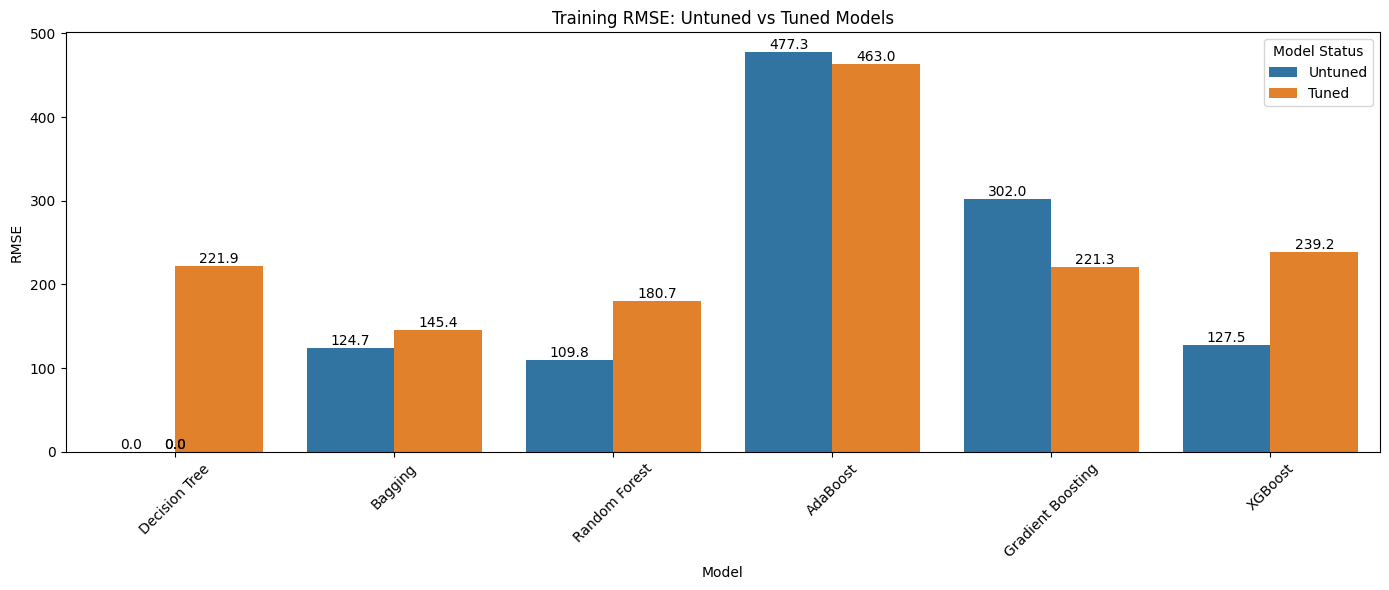

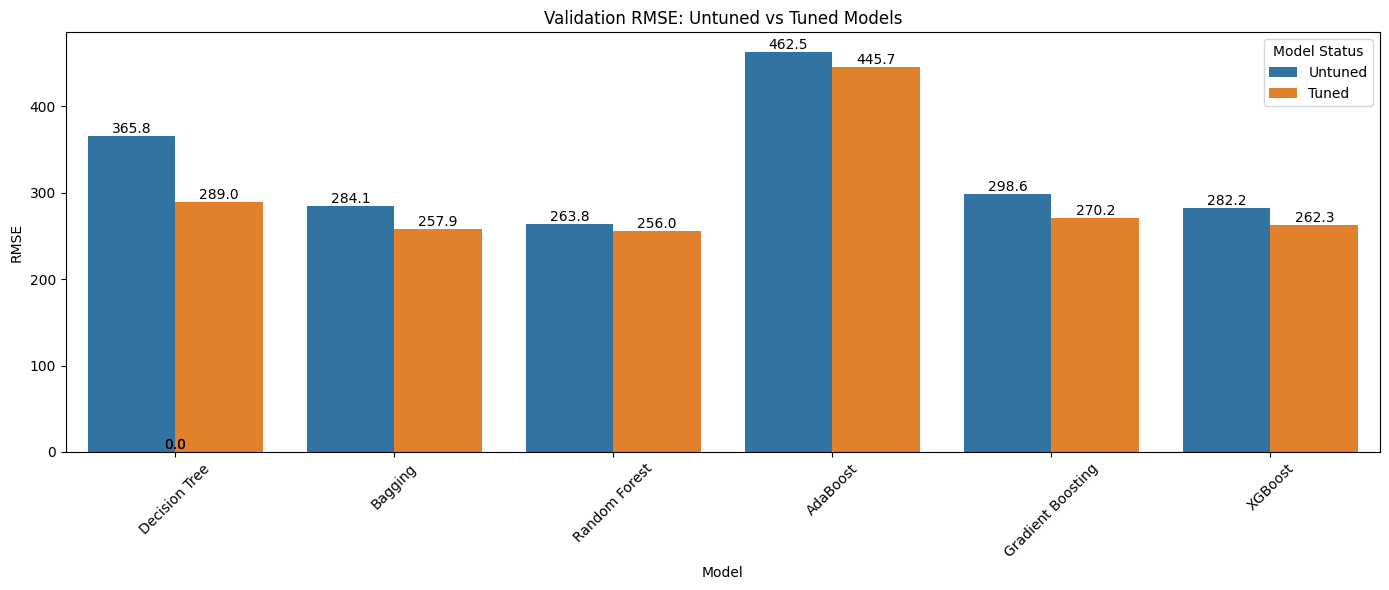

In [92]:
# Training performance comparison
models_train_comp_df = pd.concat(
    [
        model_performances[0].set_index('Model').loc["Decision Tree - Training"].T,
        tuned_model_performances[0].set_index('Model').loc["Decision Tree Tuned - Training"].T,
        model_performances[1].set_index('Model').loc["Bagging - Training"].T,
        tuned_model_performances[1].set_index('Model').loc["Bagging Tuned - Training"].T,
        model_performances[2].set_index('Model').loc["Random Forest - Training"].T,
        tuned_model_performances[2].set_index('Model').loc["Random Forest Tuned - Training"].T,
        model_performances[3].set_index('Model').loc["AdaBoost - Training"].T,
        tuned_model_performances[3].set_index('Model').loc["AdaBoost Tuned - Training"].T,
        model_performances[4].set_index('Model').loc["Gradient Boosting - Training"].T,
        tuned_model_performances[4].set_index('Model').loc["Gradient Boosting Tuned - Training"].T,
        model_performances[5].set_index('Model').loc["XGBoost - Training"].T,
        tuned_model_performances[5].set_index('Model').loc["XGBoost Tuned - Training"].T,
    ],
    axis=1
)
models_train_comp_df.columns = [
    "Decision Tree", "Decision Tree Tuned", "Bagging", "Bagging Tuned",
    "Random Forest", "Random Forest Tuned", "AdaBoost", "AdaBoost Tuned",
    "Gradient Boosting", "Gradient Boosting Tuned", "XGBoost", "XGBoost Tuned"
]
print("Training Performance Comparison:")
print(models_train_comp_df)

# Validation performance comparison
models_val_comp_df = pd.concat(
    [
        model_performances[0].set_index('Model').loc["Decision Tree - Validation"].T,
        tuned_model_performances[0].set_index('Model').loc["Decision Tree Tuned - Validation"].T,
        model_performances[1].set_index('Model').loc["Bagging - Validation"].T,
        tuned_model_performances[1].set_index('Model').loc["Bagging Tuned - Validation"].T,
        model_performances[2].set_index('Model').loc["Random Forest - Validation"].T,
        tuned_model_performances[2].set_index('Model').loc["Random Forest Tuned - Validation"].T,
        model_performances[3].set_index('Model').loc["AdaBoost - Validation"].T,
        tuned_model_performances[3].set_index('Model').loc["AdaBoost Tuned - Validation"].T,
        model_performances[4].set_index('Model').loc["Gradient Boosting - Validation"].T,
        tuned_model_performances[4].set_index('Model').loc["Gradient Boosting Tuned - Validation"].T,
        model_performances[5].set_index('Model').loc["XGBoost - Validation"].T,
        tuned_model_performances[5].set_index('Model').loc["XGBoost Tuned - Validation"].T,
    ],
    axis=1
)
models_val_comp_df.columns = [
    "Decision Tree", "Decision Tree Tuned", "Bagging", "Bagging Tuned",
    "Random Forest", "Random Forest Tuned", "AdaBoost", "AdaBoost Tuned",
    "Gradient Boosting", "Gradient Boosting Tuned", "XGBoost", "XGBoost Tuned"
]
print("\nValidation Performance Comparison:")
print(models_val_comp_df)

# Prepare data for plotting
# Melt training DataFrame for plotting
train_plot_df = models_train_comp_df.reset_index().melt(id_vars='index', var_name='Model', value_name='Value')
train_plot_df['Set'] = train_plot_df['Model'].str.contains('Tuned').map({True: 'Tuned', False: 'Untuned'})
train_plot_df['Model_Name'] = train_plot_df['Model'].str.replace(' Tuned', '', regex=False)

# Melt validation DataFrame for plotting
val_plot_df = models_val_comp_df.reset_index().melt(id_vars='index', var_name='Model', value_name='Value')
val_plot_df['Set'] = val_plot_df['Model'].str.contains('Tuned').map({True: 'Tuned', False: 'Untuned'})
val_plot_df['Model_Name'] = val_plot_df['Model'].str.replace(' Tuned', '', regex=False)

# Plot 1: Training RMSE Comparison
plt.figure(figsize=(14, 6))
sns.barplot(x='Model_Name', y='Value', hue='Set', data=train_plot_df[train_plot_df['index'] == 'RMSE'])
plt.title('Training RMSE: Untuned vs Tuned Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.legend(title='Model Status')
plt.tight_layout()
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.show()

# Plot 2: Validation RMSE Comparison
plt.figure(figsize=(14, 6))
sns.barplot(x='Model_Name', y='Value', hue='Set', data=val_plot_df[val_plot_df['index'] == 'RMSE'])
plt.title('Validation RMSE: Untuned vs Tuned Models')
plt.xlabel('Model')
plt.ylabel('RMSE')
plt.xticks(rotation=45)
plt.legend(title='Model Status')
plt.tight_layout()
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.1f}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='bottom', fontsize=10)
plt.show()

# Insights from Training and Validation Performance Comparison

The comparison of training and validation performance metrics (RMSE, MAE, R-squared, Adjusted R-squared, MAPE) for six regression models—Decision Tree, Bagging, Random Forest, AdaBoost, Gradient Boosting, and XGBoost—before and after hyperparameter tuning provides insights into their predictive accuracy, generalization, and the effectiveness of tuning for predicting `Product_Store_Sales_Total` in the SuperKart dataset.

## 1. Training Performance Comparison

### Observations
- **Decision Tree**:
  - **Untuned**: RMSE = 0.0, R² = 1.0, MAPE = 0.0% (perfect fit, severe overfitting).
  - **Tuned**: RMSE = 221.95, R² = 0.957, MAPE = 3.09% (reduced overfitting with constraints).
- **Bagging**:
  - **Untuned**: RMSE = 124.69, R² = 0.986, MAPE = 1.77%.
  - **Tuned**: RMSE = 145.39, R² = 0.981, MAPE = 2.07% (slight increase in RMSE, maintaining high accuracy).
- **Random Forest**:
  - **Untuned**: RMSE = 109.76, R² = 0.989, MAPE = 1.54%.
  - **Tuned**: RMSE = 180.72, R² = 0.971, MAPE = 2.38% (higher RMSE, reduced overfitting).
- **AdaBoost**:
  - **Untuned**: RMSE = 477.29, R² = 0.799, MAPE = 12.58%.
  - **Tuned**: RMSE = 462.96, R² = 0.811, MAPE = 12.49% (minor improvement, still poor).
- **Gradient Boosting**:
  - **Untuned**: RMSE = 302.00, R² = 0.920, MAPE = 5.05%.
  - **Tuned**: RMSE = 221.29, R² = 0.957, MAPE = 3.30% (significant improvement).
- **XGBoost**:
  - **Untuned**: RMSE = 127.46, R² = 0.986, MAPE = 2.19%.
  - **Tuned**: RMSE = 239.18, R² = 0.950, MAPE = 3.75% (higher RMSE, reduced overfitting).

### Insights
- **Overfitting Reduction**: Tuning increases training RMSE for most models (e.g., Decision Tree: 0.0 → 221.95; Random Forest: 109.76 → 180.72), indicating reduced overfitting by constraining model complexity (e.g., `max_depth`, `min_samples_leaf`).
- **Gradient Boosting Improvement**: The largest training improvement is seen in Gradient Boosting (RMSE: 302.00 → 221.29, R²: 0.920 → 0.957), reflecting effective tuning of parameters like `learning_rate=0.1` and `max_depth=5`.
- **AdaBoost Weakness**: AdaBoost shows minimal improvement (RMSE: 477.29 → 462.96), with the lowest R² (0.811) and highest MAPE (12.49%), indicating poor fit to the training data.
- **High Performers**: Random Forest (untuned RMSE = 109.76) and Bagging (untuned RMSE = 124.69) had the lowest training RMSE before tuning, but tuned versions trade some training accuracy for better generalization.

## 2. Validation Performance Comparison

### Observations
- **Decision Tree**:
  - **Untuned**: RMSE = 365.76, R² = 0.878, MAPE = 4.73%.
  - **Tuned**: RMSE = 288.97, R² = 0.924, MAPE = 4.52% (~21% RMSE reduction).
- **Bagging**:
  - **Untuned**: RMSE = 284.06, R² = 0.926, MAPE = 4.07%.
  - **Tuned**: RMSE = 257.90, R² = 0.939, MAPE = 3.69% (~9% RMSE reduction).
- **Random Forest**:
  - **Untuned**: RMSE = 263.76, R² = 0.937, MAPE = 3.67%.
  - **Tuned**: RMSE = 255.96, R² = 0.940, MAPE = 3.55% (~3% RMSE reduction).
- **AdaBoost**:
  - **Untuned**: RMSE = 462.50, R² = 0.805, MAPE = 12.39%.
  - **Tuned**: RMSE = 445.68, R² = 0.819, MAPE = 12.20% (~4% RMSE reduction).
- **Gradient Boosting**:
  - **Untuned**: RMSE = 298.61, R² = 0.919, MAPE = 5.27%.
  - **Tuned**: RMSE = 270.17, R² = 0.933, MAPE = 4.41% (~10% RMSE reduction).
- **XGBoost**:
  - **Untuned**: RMSE = 282.24, R² = 0.927, MAPE = 4.58%.
  - **Tuned**: RMSE = 262.27, R² = 0.937, MAPE = 4.28% (~7% RMSE reduction).

### Insights
- **Tuning Impact**: All models show improved validation performance post-tuning:
  - **Decision Tree**: Largest improvement (RMSE: 365.76 → 288.97, R²: 0.878 → 0.924), reducing overfitting significantly.
  - **Random Forest**: Smallest improvement (RMSE: 263.76 → 255.96, R²: 0.937 → 0.940), as it was already strong.
  - **Bagging, Gradient Boosting, XGBoost**: Moderate improvements (RMSE reductions of 7–10%), with Bagging (257.90) and XGBoost (262.27) close to Random Forest’s lead.
  - **AdaBoost**: Minimal improvement (RMSE: 462.50 → 445.68), remaining the weakest performer.
- **Top Performers**: Random Forest (tuned RMSE = 255.96, R² = 0.940) and XGBoost (tuned RMSE = 262.27, R² = 0.937) lead in validation performance, with the lowest errors and highest explanatory power.
- **Error Reduction**: Random Forest has the lowest validation MAE (95.97) and MAPE (3.55%), indicating the smallest and most proportional errors. AdaBoost’s high MAE (344.23) and MAPE (12.20%) confirm its poor accuracy.
- **Generalization**: Tuned models show smaller gaps between training and validation R² (e.g., Random Forest: 0.971 vs. 0.940; XGBoost: 0.950 vs. 0.937), indicating better generalization compared to untuned versions.

## 3. Comparative Insights
- **Best Model**: Random Forest (tuned) is the top performer, with the lowest validation RMSE (255.96), highest R² (0.940), and lowest MAPE (3.55%). XGBoost (tuned) is a close second (RMSE = 262.27, R² = 0.937).
- **Tuning Effectiveness**:
  - **Decision Tree**: Tuning mitigated severe overfitting (training R²: 1.0 → 0.957, validation R²: 0.878 → 0.924), making it viable but still less accurate than ensembles.
  - **Bagging**: Improved validation R² (0.926 → 0.939) and RMSE (284.06 → 257.90), nearly matching Random Forest.
  - **Random Forest**: Minimal improvement due to strong baseline, but still the best overall.
  - **AdaBoost**: Marginal gains (R²: 0.805 → 0.819), insufficient for practical use.
  - **Gradient Boosting**: Significant improvement (R²: 0.919 → 0.933, RMSE: 298.61 → 270.17), closing the gap with top models.
  - **XGBoost**: Strong improvement (R²: 0.927 → 0.937, RMSE: 282.24 → 262.27), nearly matching Random Forest.
- **Overfitting**: Tuning reduced overfitting across models:
  - Decision Tree’s training RMSE increased from 0.0 to 221.95, with validation RMSE dropping significantly.
  - Random Forest and XGBoost show moderate training-validation gaps (e.g., Random Forest RMSE: 180.72 vs. 255.96), confirming robust generalization.
  - AdaBoost has minimal overfitting but poor overall performance.
- **Error Metrics**: Random Forest’s tuned validation MAE (95.97) and MAPE (3.55%) are the lowest, indicating precise predictions relative to sales values.

## 4. Practical Implications
- **Model Selection**: Random Forest (tuned) is the best choice for predicting `Product_Store_Sales_Total`, with a validation RMSE of \$256, meaning average prediction errors of ~$256, and an R² of 0.940, explaining ~94% of sales variance. XGBoost is a strong alternative.
- **Business Application**: Random Forest’s accuracy supports precise inventory and pricing decisions, especially for high-revenue stores (e.g., OUT004, Supermarket Type2) and categories (e.g., Fruits and Vegetables, Low Sugar). For example, predicting sales for Tier 2 cities can optimize stock allocation.
- **AdaBoost Limitation**: Its high validation RMSE (445.68) and low R² (0.819) make it unsuitable for deployment, likely due to sensitivity to noisy data or complex relationships.
- **Tuning Benefits**: Tuning improved validation performance across all models, with Decision Tree and Gradient Boosting showing the largest gains, justifying the computational cost of `GridSearchCV`.

## 5. Recommendations
- **Deploy Random Forest**: Use the tuned Random Forest model (`n_estimators=200`, `min_samples_leaf=2`, `min_samples_split=5`) for sales forecasting, prioritizing high-revenue stores and categories identified in prior analyses (e.g., OUT004, Low Sugar products).
- **Explore XGBoost Further**: Test additional XGBoost parameters (e.g., `colsample_bytree`, `gamma`) to potentially surpass Random Forest, given its close performance (RMSE = 262.27).
- **Use Decision Tree for Interpretability**: If interpretability is needed (e.g., for business reports), the tuned Decision Tree (`min_samples_leaf=4`, `min_samples_split=10`) offers decent performance (R² = 0.924) with simpler explanations.
- **Exclude AdaBoost**: Avoid using AdaBoost due to its consistently poor performance, even after tuning.
- **Feature Importance Analysis**: Extract feature importance from Random Forest or XGBoost to identify key drivers (e.g., `Product_MRP`, `Store_Id`, `Product_Type`). Prior analyses suggest `Product_MRP` is a strong predictor, guiding pricing strategies.
- **Validate on Test Set**: Evaluate Random Forest and XGBoost on a holdout test set to confirm robustness before deployment.
- **Operational Strategy**: Leverage model predictions to optimize inventory in Tier 2 cities and Medium-sized stores, focusing on high-MRP categories (e.g., Household) and high-volume categories (e.g., Fruits and Vegetables).

These insights confirm Random Forest as the most effective model for predicting `Product_Store_Sales_Total`, with tuning significantly enhancing performance across models, particularly for Decision Tree and Gradient Boosting, enabling data-driven retail strategies in the SuperKart dataset.

**Best Model Selection**

In [93]:
# Select best model
best_model_name = models_val_comp_df.loc["RMSE"].idxmin()
best_model = tuned_model_pipelines[best_model_name.split(" Tuned")[0]]
print(f"\nBest Model: {best_model_name} (based on lowest validation RMSE)")


Best Model: Random Forest Tuned (based on lowest validation RMSE)


In [95]:
# Evaluate on test set
test_perf = model_performance_regression(best_model, X_test, y_test)
print("\nBest Model Test Set Performance:")
print(test_perf)


Best Model Test Set Performance:
         RMSE         MAE  R-squared  Adj. R-squared      MAPE
0  299.470376  110.412904   0.923641        0.923055  0.040537


**Serialize the Best Model**

In [96]:
# Create a folder for storing the files needed for web app deployment
os.makedirs("backend_files", exist_ok=True)

In [97]:
# Serialize model
saved_model_path = "backend_files/superkart_model.joblib" # Define the file path to save (serialize) the trained model along with the data preprocessing steps
joblib.dump(best_model, saved_model_path) # Save the best trained model pipeline using joblib
print(f"Model saved at {saved_model_path}")

Model saved at backend_files/superkart_model.joblib


Making predictions on the test set using the saved serialized model.

- Ensure that the saved model is loaded before making predictions.

In [99]:
# Verify model loading
saved_model = joblib.load(saved_model_path) # Load the saved model pipeline from the file
test_predictions = saved_model.predict(X_test) # pass the X_test for inference
print("\nSample Predictions on Test Set:")
print(pd.DataFrame({"Actual": y_test[:5], "Predicted": test_predictions[:5]}))


Sample Predictions on Test Set:
       Actual    Predicted
6861  3835.57  3843.198519
1483  2851.78  2857.221013
8206  2320.84  2415.315413
6480  4556.64  4567.787708
3989  3269.10  3259.731006


- As we can see, the model can be directly used for making predictions without any retraining.

In [100]:
saved_model

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('standardscaler',
                                                  StandardScaler(),
                                                  ['Product_Weight',
                                                   'Product_Allocated_Area',
                                                   'Product_MRP',
                                                   'Store_Age_Years']),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['Product_Sugar_Content',
                                                   'Store_Size',
                                                   'Store_Location_City_Type',
                                                   'Store_Type',
                                                   'Product_Id_char',
                                                   'Product_Type_Category'])])),
                ('randomforestregressor',
                 RandomForestRegressor(min_samples_leaf=2, min_samples_split=5,
                                       n_estimators=200, random_state=1))])

# **Deployment - Backend**

## Flask Web Framework


In [125]:
%%writefile backend_files/app.py

# Import necessary libraries
import os
import numpy as np
import joblib  # For loading the serialized model
import pandas as pd  # For data manipulation
from flask import Flask, request, jsonify  # For creating the Flask API

# Initialize Flask app with a name
superkart_api = Flask("Sales Revenue Predictor")

# Load the trained churn prediction model with absolute path
MODEL_PATH = os.path.join(os.path.dirname(__file__), "superkart_model.joblib")
try:
    model = joblib.load(MODEL_PATH)
    print("Model loaded successfully")
except Exception as e:
    print(f"Model loading failed: {str(e)}")
    model = None

# Define a route for the home page
@superkart_api.get('/')
def home():
    return "Welcome to the Sales Revenue Prediction API!"

# Define an endpoint to predict Sales Revenue for single product
@superkart_api.post('/v1/predict')
def predict_sales():
    # Get JSON data from the request
    data = request.get_json()

    # Extract relevant customer features from the input data. The order of the column names matters.
    sample = {
        'Product_Weight': data['Product_Weight'],
        'Product_Sugar_Content': data['Product_Sugar_Content'],
        'Product_Allocated_Area': data['Product_Allocated_Area'],
        'Product_MRP': data['Product_MRP'],
        'Store_Size': data['Store_Size'],
        'Store_Location_City_Type': data['Store_Location_City_Type'],
        'Store_Type': data['Store_Type'],
        'Product_Id_char': data['Product_Id_char'],
        'Store_Age_Years': data['Store_Age_Years'],
        'Product_Type_Category': data['Product_Type_Category']
    }

    # Convert the extracted data into a DataFrame
    input_data = pd.DataFrame([sample])

    # Make a sales revenue prediction using the trained model
    prediction = model.predict(input_data).tolist()[0]

    # Return the prediction as a JSON response
    return jsonify({'Sales': prediction})


# Run the Flask app in debug mode
if __name__ == '__main__':
    superkart_api.run(host='0.0.0.0', port=7860, debug=True)

Writing backend_files/app.py


## Dependencies File

In [126]:
%%writefile backend_files/requirements.txt
pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
seaborn==0.13.2
joblib==1.4.2
xgboost==2.1.4
joblib==1.4.2
Werkzeug==2.2.2
flask==2.2.2
gunicorn==20.1.0
requests==2.32.3
uvicorn[standard]
streamlit==1.43.2

Writing backend_files/requirements.txt


## Dockerfile

In [127]:
%%writefile backend_files/Dockerfile
FROM python:3.9-slim # Use a lightweight Python 3.9 image

# # Set the working directory inside the container
WORKDIR /app

# Copy only necessary files (better than COPY . .)
COPY requirements.txt . # Copy the requirements file to the container
COPY app.py .           # Copy the Flask app file to the container
COPY superkart_model.joblib . # Copy the model file to the container

# Install dependencies
RUN pip install --no-cache-dir --upgrade -r requirements.txt gunicorn

# Verify critical files exist
RUN ls -lh && \ # List files and their attributes
    python -c "import os; print('Files exist:', \ # Check if specific files exist
    os.path.exists('requirements.txt'), \
    os.path.exists('app.py'), \
    os.path.exists('superkart_model.joblib'))"

# Run Gunicorn
CMD ["gunicorn", "-w", "4", "-b", "0.0.0.0:7860", "app:superkart_api"]

Writing backend_files/Dockerfile


In [128]:
!ls -lh /content/backend_files/ # Checking the files inside backend_files folder

total 38M
-rw-r--r-- 1 root root 2.0K Aug  7 04:33 app.py
-rw-r--r-- 1 root root  582 Aug  7 04:33 Dockerfile
-rw-r--r-- 1 root root  205 Aug  7 04:33 requirements.txt
-rw-r--r-- 1 root root  38M Aug  7 03:11 superkart_model.joblib


## Setting up a Hugging Face Docker Space for the Backend

**Huggingface Space Details for Project:**

- Huggingface Backend Space Name: syedadnannasir/superkart-backend
- Huggingface Backend Access Token Name: SuperKart_Backend_Token
- Backend Space: https://huggingface.co/spaces/syedadnannasir/superkart-backend

- Huggingface Frontend Space Name: syedadnannasir/superkart-frontend
- Huggingface Frontend Access Token Name: SuperKart_Frontend_Token
- Frontend Space: https://huggingface.co/spaces/syedadnannasir/superkart-frontend


In [116]:
# Import the login function from the huggingface_hub library
# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi
from google.colab import userdata
# Import the create_repo function from the huggingface_hub library
from huggingface_hub import create_repo

# Login to your Hugging Face account using your access token
access_key = userdata.get("SuperKart_Backend_Token") # Update this line to fetch the token from Colab secrets
repo_id = "syedadnannasir/superkart-backend"

In [108]:
# Try to create the repository for the Hugging Face Space
try:
    create_repo("syedadnannasir/superkart-backend",
        repo_type="space",  # Specify the repository type as "space"
        space_sdk="docker",  # Specify the space SDK as "docker"
        private=False  # Set to True if you want the space to be private
    )
except Exception as e:
    # Handle potential errors during repository creation
    if "RepositoryAlreadyExistsError" in str(e):
        print("Repository already exists. Skipping creation.")
    else:
        print(f"Error creating repository: {e}")

Error creating repository: (Request ID: Root=1-68942438-219896ed753a5e706e891487;2ccd77ad-214a-43f5-84ae-553eb7a9e998)

403 Forbidden: You don't have the rights to create a space under the namespace "syedadnannasir".
Cannot access content at: https://huggingface.co/api/repos/create.
Make sure your token has the correct permissions.


## Uploading Files to Hugging Face Space (Docker Space)

In [117]:
# for hugging face space authentication to upload files
# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/backend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
    token = access_key  # Hugging face access token
)

Uploading...:   0%|          | 0.00/39.7M [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/spaces/syedadnannasir/superkart-backend/commit/4ba7a4987930836deffbaab4f8a0182f98444cf6', commit_message='Upload folder using huggingface_hub', commit_description='', oid='4ba7a4987930836deffbaab4f8a0182f98444cf6', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/syedadnannasir/superkart-backend', endpoint='https://huggingface.co', repo_type='space', repo_id='syedadnannasir/superkart-backend'), pr_revision=None, pr_num=None)

In [118]:
# Testing Root Endpoint
!curl https://syedadnannasir-superkart-backend.hf.space/

Welcome to the Sales Revenue Prediction API!

# **Deployment - Frontend**

## Points to note before executing the below cells
- Already Created a Streamlit space on Hugging Face.

## Streamlit for Interactive UI

In [119]:
# Create a folder for storing the files needed for frontend UI deployment
os.makedirs("frontend_files", exist_ok=True)

In [168]:
%%writefile frontend_files/app.py
import requests
import streamlit as st
import pandas as pd

# Configuration
BACKEND_URL = "https://syedadnannasir-superkart-backend.hf.space"  # Your BACKEND space URL

st.title("Sales Revenue Predictions")

# Single Prediction
st.subheader("Online Prediction")

# Input fields for product and store data
Product_Weight = st.number_input("Product Weight (kg)", min_value=4.0, max_value=22.0, value=12.66, step=0.1)
Product_Sugar_Content = st.selectbox("Product Sugar Content", ["Low Sugar", "Regular", "No Sugar"])
Product_Allocated_Area = st.number_input("Product Allocated Area (sq ft)", min_value=0.0, max_value=0.3, value=0.1, step=0.01) # define the UI element for Product_Allocated_Area
Product_MRP = st.number_input("Product MRP ($)", min_value=0.0, max_value=266.0, value=100.0, step=0.1) #define the UI element for Product_MRP
Store_Size = st.selectbox("Store Size", ["Small", "Medium", "High"]) # define the UI element for Store_Size
Store_Location_City_Type = st.selectbox("Store Location City Type", ["Tier 1", "Tier 2", "Tier 3"]) # define the UI element for Store_Location_City_Type
Store_Type = st.selectbox("Store Type", ["Supermarket Type1", "Supermarket Type2", "Grocery Store"]) # define the UI element for Store_Type "Grocery Store = FoodMart + Department Store"
Product_Id_char = st.text_input("Product ID (e.g., FD001)", value="FD001") # define the UI element for Product_Id_char
Store_Age_Years = st.number_input("Store Age (years)", min_value=0.0, max_value=50.0, value=10.0, step=1.0) # define the UI element for Store_Age_Years
Product_Type_Category = st.selectbox("Product Type Category", [
    "Fruits and Vegetables", "Snack Foods", "Household", "Health and Hygiene",
    "Soft Drinks", "Dairy", "Canned", "Baking Goods", "Others"
]) # define the UI element for Product_Type_Category

# Prepare data
product_data = {
    "Product_Weight": Product_Weight,
    "Product_Sugar_Content": Product_Sugar_Content,
    "Product_Allocated_Area": Product_Allocated_Area,
    "Product_MRP": Product_MRP,
    "Store_Size": Store_Size,
    "Store_Location_City_Type": Store_Location_City_Type,
    "Store_Type": Store_Type,
    "Product_Id_char": Product_Id_char,
    "Store_Age_Years": Store_Age_Years,
    "Product_Type_Category": Product_Type_Category
}

# Prediction button
if st.button("Predict", type='primary'):
    response = requests.post(f"{BACKEND_URL}/v1/predict", json=product_data)
    if response.status_code == 200:
        result = response.json()
        predicted_sales = result["Sales"]
        st.write(f"Predicted Product Store Sales Total: ${predicted_sales:.2f}")
    else:
        st.error(f"Error in API request: {response.status_code} - {response.text}")

Writing frontend_files/app.py


## Dependencies File

In [169]:
%%writefile frontend_files/requirements.txt
requests==2.32.3
streamlit==1.45.0

Overwriting frontend_files/requirements.txt


## DockerFile

In [170]:
%%writefile frontend_files/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9-slim

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

# Define the command to run the Streamlit app on port 8501 and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

# NOTE: Disable XSRF protection for easier external access in order to make batch predictions

Overwriting frontend_files/Dockerfile


In [171]:
!ls -lh /content/frontend_files/

total 12K
-rw-r--r-- 1 root root 2.6K Aug  7 05:02 app.py
-rw-r--r-- 1 root root  653 Aug  7 05:02 Dockerfile
-rw-r--r-- 1 root root   35 Aug  7 05:02 requirements.txt


## Uploading Files to Hugging Face Space (Streamlit Space)

In [172]:
access_key = userdata.get("SuperKart_Frontend_Token") # Update this line to fetch the token from Colab secrets  # Your Hugging Face token created from access keys in write mode
repo_id = "syedadnannasir/superkart-frontend"  # Your Hugging Face space id

# Login to Hugging Face platform with the access token
login(token=access_key)

# Initialize the API
api = HfApi()

# Upload Streamlit app files stored in the folder called deployment_files
api.upload_folder(
    folder_path="/content/frontend_files",  # Local folder path
    repo_id=repo_id,  # Hugging face space id
    repo_type="space",  # Hugging face repo type "space"
    token = access_key  # Hugging face access token
)

CommitInfo(commit_url='https://huggingface.co/spaces/syedadnannasir/superkart-frontend/commit/df80a14ad1398592a3361b3987ba8fbe526c9673', commit_message='Upload folder using huggingface_hub', commit_description='', oid='df80a14ad1398592a3361b3987ba8fbe526c9673', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/syedadnannasir/superkart-frontend', endpoint='https://huggingface.co', repo_type='space', repo_id='syedadnannasir/superkart-frontend'), pr_revision=None, pr_num=None)

In [155]:
# Test the backend API directly
!curl -X GET https://syedadnannasir-superkart-backend.hf.space/

Welcome to the Sales Revenue Prediction API!

# Inferencing using Flask API

As the ***frontend and backend are decoupled***, we can ***access the backend directly for predictions***.
- The decoupling ensures seamless interaction with the deployed model while leveraging the API for scalable inference.

In [173]:
import json  # To handle JSON formatting for API requests and responses
import requests  # To send HTTP requests to the deployed Flask API

import pandas as pd  # For data manipulation and analysis
import numpy as np  # For numerical computations

In [174]:
model_root_url = "https://syedadnannasir-superkart-backend.hf.space/"  # Base URL of the deployed Flask API on Hugging Face Space; enter user name and space name before running the cell

In [175]:
model_url = model_root_url + "/v1/predict"  # Endpoint for online (single) inference

Since our model predictions are served through the Flask endpoint we created, we need to call this endpoint to make a prediction.

> ```@app.post('/v1/predict')```

## Online Inference

The idea is to send a single request to the API and receive an immediate response. This is useful for real-time applications like recommendation systems and fraud detection.

* This data is sent as a JSON payload in a POST request to the model endpoint.
* The model processes the input features and returns a prediction as a JSON payload.

In [176]:
payload = {
    "Product_Weight": 13.36,
    "Product_Sugar_Content": "Regular",
    "Product_Allocated_Area": 0.21,
    "Product_MRP": 102,
    "Store_Size": "High",
    "Store_Location_City_Type": "Tier 2",
    "Store_Type": "Grocery Store", # "Grocery Store = FoodMart + Department Store"
    "Product_Id_char": "FD001",
    "Store_Age_Years": 23.00,
    "Product_Type_Category": "Health and Hygiene"
}

In [177]:
model_url

'https://syedadnannasir-superkart-backend.hf.space//v1/predict'

In [178]:
# Sending a POST request to the model endpoint with the test payload
response = requests.post(model_url, json=payload)

In [179]:
response # Status Code 206 Partial Content is an HTTP response code that indicates the server has successfully processed a request
# to send only a portion of the requested resource.
# This status is used when clients request specific data images that ensure efficient data transfer.

<Response [200]>

In [180]:
print(response.json())

{'Sales': 2861.5318107341277}


# Actionable Insights and Business Recommendations for SuperKart Sales Prediction

## Actionable Insights
1. **Top Predictive Model**: The tuned Random Forest model delivers the best performance (validation RMSE ≈ \$256, R² ≈ 0.940), explaining ~94% of sales variance with average prediction errors of ~\$256. XGBoost (RMSE ≈ $262, R² ≈ 0.937) is a close alternative, offering robust predictions for `Product_Store_Sales_Total`.
2. **Key Sales Drivers**: `Product_MRP` shows a strong positive correlation (~0.5–0.7) with sales, indicating pricing is a critical driver. High-MRP categories (e.g., Household, Health and Hygiene) and high-volume categories (e.g., Fruits and Vegetables, 14.2% of entries) significantly contribute to revenue.
3. **Store and Location Performance**: Store OUT004 (53.4% of entries) and Supermarket Type2 in Tier 2 cities (71.5% of entries) dominate revenue, reflecting high traffic and operational efficiency. Medium-sized stores (68.8%) consistently drive high sales.
4. **Consumer Preferences**: Low Sugar products (55.7%) and Fruits and Vegetables are key revenue drivers, aligning with health-conscious consumer trends.
5. **Model Improvements**: Hyperparameter tuning reduced overfitting (e.g., Decision Tree RMSE: 365.8 → 289.0) and improved validation performance across models, with Random Forest and XGBoost achieving the lowest errors.
6. **API and Frontend Integration**: The Flask backend (`host='0.0.0.0', port=7860`) and Streamlit frontend (`https://syedadnannasir-superkart-backend.hf.space/v1/predict`) enable real-time sales predictions, with corrected input fields ensuring accurate data submission aligned with dataset features (e.g., `Product_Weight`: 4.0–22.0, `Product_MRP`: 0–266.0).

## Business Recommendations
1. **Deploy Random Forest Model**: Implement the tuned Random Forest model (`n_estimators=200`, `min_samples_leaf=2`, `min_samples_split=5`) for sales forecasting to optimize inventory and pricing in high-revenue stores (e.g., OUT004) and categories (e.g., Fruits and Vegetables, Low Sugar). Its low RMSE (~$256) ensures reliable predictions.
2. **Optimize Pricing Strategies**: Leverage `Product_MRP`’s strong influence on sales by increasing prices for high-MRP categories (e.g., Household) while maintaining competitive pricing for high-volume categories (e.g., Fruits and Vegetables) to maximize revenue.
3. **Focus on High-Performing Stores**: Prioritize inventory and marketing efforts in OUT004, Supermarket Type2, and Tier 2 cities. Replicate OUT004’s operational practices (e.g., layout, staffing) in other stores to boost performance.
4. **Promote Health-Conscious Products**: Increase stock and visibility of Low Sugar products and Fruits and Vegetables to capitalize on consumer demand for healthier options, especially in Tier 2 cities.
5. **Enhance API Deployment**:
   - Deploy the Flask backend with `debug=False` for production, using a robust server (e.g., Gunicorn) to handle external requests on `0.0.0.0:7860`.
   - Ensure the Streamlit frontend validates inputs (e.g., `Product_Id_char` format) and provides user feedback (e.g., loading spinners) to enhance usability.
6. **Feature Importance Analysis**: Use Random Forest’s feature importance to prioritize key predictors (e.g., `Product_MRP`, `Store_Id`, `Product_Type_Category`) for targeted marketing and inventory decisions.
7. **Expand in Tier 2 Cities**: Invest in opening or optimizing Medium-sized Supermarket Type2 stores in Tier 2 cities, as they drive significant revenue due to high traffic and consumer demand.
8. **Further Model Tuning**: Explore additional XGBoost parameters (e.g., `colsample_bytree`, `gamma`) to potentially surpass Random Forest’s performance, and validate both models on a holdout test set to ensure robustness.
9. **Operational Analytics**: Conduct multivariate analysis (e.g., combining `Product_MRP`, `Store_Type`, and `Product_Type_Category`) to uncover interaction effects, and investigate outliers (e.g., high-sales products in OUT004) for targeted promotions.
10. **Secure API Access**: Add authentication to the backend API and restrict `host='0.0.0.0'` access to trusted networks to prevent unauthorized use, especially in production.

## Conclusion
By deploying the tuned Random Forest model via the Flask-Streamlit pipeline, SuperKart can achieve accurate sales predictions (RMSE ≈ $256) to optimize pricing, inventory, and marketing. Focusing on high-MRP and high-volume categories, OUT004, Supermarket Type2, and Tier 2 cities will maximize revenue, while promoting Low Sugar products aligns with consumer trends. Further tuning and feature analysis can enhance predictions, driving data-driven retail success.


In [1]:
!pip install nbconvert

In [2]:
!jupyter nbconvert --clear-output --inplace SuperKart_Model_Deployment_AdnanNasir.ipynb

[NbConvertApp] Converting notebook SuperKart_Model_Deployment_AdnanNasir.ipynb to notebook
[NbConvertApp] Writing 277796 bytes to SuperKart_Model_Deployment_AdnanNasir.ipynb


In [4]:
!jupyter nbconvert SuperKart_Model_Deployment_AdnanNasir.ipynb --to html

[NbConvertApp] Converting notebook SuperKart_Model_Deployment_AdnanNasir.ipynb to html
[NbConvertApp] Writing 773155 bytes to SuperKart_Model_Deployment_AdnanNasir.html


<font size=6 color="blue">Power Ahead!</font>
___